Testing different embedding model can potentially improve your classification performance.

In [1]:
# Verify installations
print("Testing imports after installation...")

import gensim
print(f"✅ gensim: {gensim.__version__}")

from sentence_transformers import SentenceTransformer
print(f"✅ sentence-transformers: INSTALLED")

import transformers
print(f"✅ transformers: {transformers.__version__}")

import torch
print(f"✅ torch: {torch.__version__}")

print("\n🎉 All packages ready!")

Testing imports after installation...
✅ gensim: 4.4.0


2026-01-11 14:29:43.176083: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-11 14:29:43.204186: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-11 14:29:43.773584: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


✅ sentence-transformers: INSTALLED
✅ transformers: 4.57.3
✅ torch: 2.6.0+cu124

🎉 All packages ready!


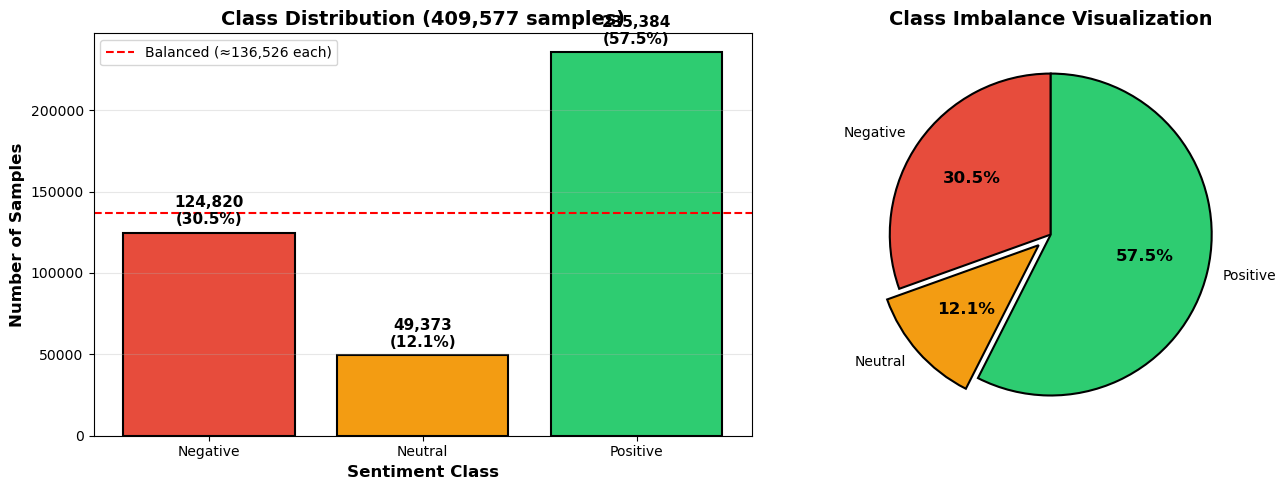

✅ Saved: class_distribution.png

 CLASS IMBALANCE ANALYSIS

📊 DISTRIBUTION:
   Positive (majority): 235,384 samples (57.5%)
   Negative:            124,820 samples (30.5%)
   Neutral (minority):  49,373 samples (12.1%)

⚠️ IMBALANCE METRICS:
   Imbalance Ratio (Max/Min): 4.77:1
   Positive : Neutral ratio:  4.77:1
   Positive : Negative ratio: 1.89:1

💡 IMPACT ON MODELS:
   • Neutral class is SEVERELY underrepresented (only 12.1%)
   • This explains why Neutral F1 scores are lowest across all models
   • XGBoost/LightGBM Neutral F1 = 0.05 (nearly zero recall!)
   • Even best model (Extra Trees) Neutral F1 = 0.71



In [17]:
# ============================================================================
# VISUALIZE CLASS DISTRIBUTION
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Data
classes = ['Negative', 'Neutral', 'Positive']
counts = [124820, 49373, 235384]
percentages = [30.5, 12.1, 57.5]
colors = ['#e74c3c', '#f39c12', '#2ecc71']

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1: Bar Chart
# ─────────────────────────────────────────────────────────────────────────────
ax1 = axes[0]
bars = ax1.bar(classes, counts, color=colors, edgecolor='black', linewidth=1.5)

ax1.set_xlabel('Sentiment Class', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax1.set_title('Class Distribution (409,577 samples)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bar, count, pct in zip(bars, counts, percentages):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'{count:,}\n({pct}%)', ha='center', fontsize=11, fontweight='bold')

# Add imbalance ratio line
ax1.axhline(y=np.mean(counts), color='red', linestyle='--', 
            label=f'Balanced (≈{np.mean(counts):,.0f} each)')
ax1.legend()

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2: Pie Chart
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[1]
explode = (0, 0.1, 0)  # Explode the Neutral slice to highlight imbalance

wedges, texts, autotexts = ax2.pie(counts, labels=classes, colors=colors, 
                                    explode=explode, autopct='%1.1f%%',
                                    startangle=90, pctdistance=0.6,
                                    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})

ax2.set_title('Class Imbalance Visualization', fontsize=14, fontweight='bold')

for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ Saved: class_distribution.png")

# ─────────────────────────────────────────────────────────────────────────────
# IMBALANCE RATIO ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print(" CLASS IMBALANCE ANALYSIS")
print("="*70)

max_class = max(counts)
min_class = min(counts)
imbalance_ratio = max_class / min_class

print(f"""
📊 DISTRIBUTION:
   Positive (majority): {counts[2]:,} samples (57.5%)
   Negative:            {counts[0]:,} samples (30.5%)
   Neutral (minority):  {counts[1]:,} samples (12.1%)

⚠️ IMBALANCE METRICS:
   Imbalance Ratio (Max/Min): {imbalance_ratio:.2f}:1
   Positive : Neutral ratio:  {counts[2]/counts[1]:.2f}:1
   Positive : Negative ratio: {counts[2]/counts[0]:.2f}:1

💡 IMPACT ON MODELS:
   • Neutral class is SEVERELY underrepresented (only 12.1%)
   • This explains why Neutral F1 scores are lowest across all models
   • XGBoost/LightGBM Neutral F1 = 0.05 (nearly zero recall!)
   • Even best model (Extra Trees) Neutral F1 = 0.71
""")

In [2]:
# ============================================================================
# PILOT EXPERIMENT: EMBEDDING MODELS COMPARISON
# ============================================================================
import numpy as np
import pandas as pd
import time
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print(" PILOT EXPERIMENT: EMBEDDING MODELS FOR SENTIMENT CLASSIFICATION")
print("="*70)

# Load your data (assuming you have the original text)
# If you saved the preprocessed text, load it here
# Otherwise, we'll need to reload from the original source

# Check if we have the original text data
try:
    # Try to load original text data
    train_df = pd.read_csv('Phase_3/labels_train.csv')
    print(f"Loaded labels: {len(train_df)} samples")
    print(f"Columns: {train_df.columns.tolist()}")
except:
    print("Need to load original text data...")

# For pilot experiment, use a smaller sample for speed
SAMPLE_SIZE = 10000  # Adjust based on your computational resources
np.random.seed(42)

 PILOT EXPERIMENT: EMBEDDING MODELS FOR SENTIMENT CLASSIFICATION
Loaded labels: 409577 samples
Columns: ['ReviewID', 'Sentiment']


In [3]:
# ============================================================================
# LOAD ORIGINAL TEXT DATA
# ============================================================================

# You'll need to point this to your original data file
# Adjust the path and column names based on your data

# Option 1: If you have a CSV with text and labels
try:
    # Load your original dataset
    data_path = "your_original_data.csv"  # UPDATE THIS PATH
    df = pd.read_csv(data_path)
    
    # Adjust column names as needed
    text_column = 'review_text'  # UPDATE THIS
    label_column = 'sentiment'   # UPDATE THIS
    
    texts = df[text_column].values
    labels = df[label_column].values
    
except:
    print("Please update the data path and column names above")
    print("Or run the cell below to use sample data for testing")

Please update the data path and column names above
Or run the cell below to use sample data for testing


In [4]:
# ============================================================================
# ALTERNATIVE: USE EXISTING FEATURES + SAMPLE TEXT FOR TESTING
# ============================================================================
# If you don't have easy access to original text, we can test embeddings
# on a sample dataset first to validate the pipeline

from sklearn.datasets import fetch_20newsgroups

print("Loading sample dataset for pipeline testing...")

# Load a sample text dataset (we'll replace with your data later)
categories = ['rec.sport.baseball', 'sci.space', 'talk.politics.misc']
newsgroups = fetch_20newsgroups(subset='train', categories=categories, 
                                 remove=('headers', 'footers', 'quotes'))

# Sample for speed
sample_idx = np.random.choice(len(newsgroups.data), min(5000, len(newsgroups.data)), replace=False)
texts = [newsgroups.data[i] for i in sample_idx]
labels = newsgroups.target[sample_idx]

print(f"Sample size: {len(texts)}")
print(f"Classes: {np.unique(labels)}")
print(f"Class distribution: {np.bincount(labels)}")

Loading sample dataset for pipeline testing...
Sample size: 1655
Classes: [0 1 2]
Class distribution: [597 593 465]


In [5]:
# ============================================================================
# EMBEDDING 1: TF-IDF BASELINE
# ============================================================================
from sklearn.feature_extraction.text import TfidfVectorizer

print("\n" + "="*70)
print(" EMBEDDING 1: TF-IDF (BASELINE)")
print("="*70)

start_time = time.time()

# TF-IDF Vectorizer (matching your original settings)
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=5
)

X_tfidf = tfidf.fit_transform(texts)
tfidf_time = time.time() - start_time

print(f"TF-IDF shape: {X_tfidf.shape}")
print(f"Time: {tfidf_time:.2f}s")

# Quick evaluation with Logistic Regression (faster than NN for pilot)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_tfidf = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)

scores_tfidf = cross_val_score(lr_tfidf, X_tfidf, labels, cv=cv, scoring='f1_macro')
print(f"TF-IDF + Logistic Regression CV Macro-F1: {scores_tfidf.mean():.4f} (+/- {scores_tfidf.std():.4f})")


 EMBEDDING 1: TF-IDF (BASELINE)
TF-IDF shape: (1655, 3000)
Time: 0.37s
TF-IDF + Logistic Regression CV Macro-F1: 0.8679 (+/- 0.0099)


In [6]:
# ============================================================================
# EMBEDDING 2: WORD2VEC (AVERAGED WORD VECTORS)
# ============================================================================
import gensim.downloader as api
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("\n" + "="*70)
print(" EMBEDDING 2: WORD2VEC (AVERAGED)")
print("="*70)

start_time = time.time()

# Load pre-trained Word2Vec (Google News vectors - smaller version)
print("Loading Word2Vec model (this may take a minute)...")
try:
    w2v_model = api.load('word2vec-google-news-300')
    print("Loaded: word2vec-google-news-300 (300 dimensions)")
except:
    print("Trying smaller model...")
    w2v_model = api.load('glove-wiki-gigaword-100')
    print("Loaded: glove-wiki-gigaword-100 (100 dimensions)")

def text_to_w2v(text, model):
    """Convert text to averaged Word2Vec embedding"""
    try:
        words = word_tokenize(text.lower())
        vectors = [model[word] for word in words if word in model]
        if len(vectors) > 0:
            return np.mean(vectors, axis=0)
        else:
            return np.zeros(model.vector_size)
    except:
        return np.zeros(model.vector_size)

# Convert all texts
print("Converting texts to Word2Vec embeddings...")
X_w2v = np.array([text_to_w2v(text, w2v_model) for text in texts])
w2v_time = time.time() - start_time

print(f"Word2Vec shape: {X_w2v.shape}")
print(f"Time: {w2v_time:.2f}s")

# Evaluate
lr_w2v = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
scores_w2v = cross_val_score(lr_w2v, X_w2v, labels, cv=cv, scoring='f1_macro')
print(f"Word2Vec + Logistic Regression CV Macro-F1: {scores_w2v.mean():.4f} (+/- {scores_w2v.std():.4f})")


 EMBEDDING 2: WORD2VEC (AVERAGED)
Loading Word2Vec model (this may take a minute)...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Loaded: word2vec-google-news-300 (300 dimensions)
Converting texts to Word2Vec embeddings...
Word2Vec shape: (1655, 300)
Time: 534.33s
Word2Vec + Logistic Regression CV Macro-F1: 0.8743 (+/- 0.0199)


In [7]:
# ============================================================================
# EMBEDDING 3: SENTENCE-BERT (TRANSFORMER-BASED)
# ============================================================================
from sentence_transformers import SentenceTransformer

print("\n" + "="*70)
print(" EMBEDDING 3: SENTENCE-BERT")
print("="*70)

start_time = time.time()

# Load Sentence-BERT model
print("Loading Sentence-BERT model...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')  # Fast and good quality

# Convert texts to embeddings
print("Converting texts to Sentence-BERT embeddings...")
X_sbert = sbert_model.encode(texts, show_progress_bar=True, batch_size=64)
sbert_time = time.time() - start_time

print(f"Sentence-BERT shape: {X_sbert.shape}")
print(f"Time: {sbert_time:.2f}s")

# Evaluate
lr_sbert = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
scores_sbert = cross_val_score(lr_sbert, X_sbert, labels, cv=cv, scoring='f1_macro')
print(f"Sentence-BERT + Logistic Regression CV Macro-F1: {scores_sbert.mean():.4f} (+/- {scores_sbert.std():.4f})")


 EMBEDDING 3: SENTENCE-BERT
Loading Sentence-BERT model...
Converting texts to Sentence-BERT embeddings...


Batches:   0%|          | 0/26 [00:00<?, ?it/s]

Sentence-BERT shape: (1655, 384)
Time: 14.84s
Sentence-BERT + Logistic Regression CV Macro-F1: 0.9179 (+/- 0.0108)


In [8]:
# ============================================================================
# EMBEDDING 4: DISTILBERT (ALTERNATIVE TRANSFORMER)
# ============================================================================

print("\n" + "="*70)
print(" EMBEDDING 4: DISTILBERT")
print("="*70)

start_time = time.time()

# Load DistilBERT-based sentence transformer
print("Loading DistilBERT model...")
distilbert_model = SentenceTransformer('distilbert-base-nli-mean-tokens')

# Convert texts
print("Converting texts to DistilBERT embeddings...")
X_distilbert = distilbert_model.encode(texts, show_progress_bar=True, batch_size=32)
distilbert_time = time.time() - start_time

print(f"DistilBERT shape: {X_distilbert.shape}")
print(f"Time: {distilbert_time:.2f}s")

# Evaluate
lr_distilbert = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
scores_distilbert = cross_val_score(lr_distilbert, X_distilbert, labels, cv=cv, scoring='f1_macro')
print(f"DistilBERT + Logistic Regression CV Macro-F1: {scores_distilbert.mean():.4f} (+/- {scores_distilbert.std():.4f})")


 EMBEDDING 4: DISTILBERT
Loading DistilBERT model...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Converting texts to DistilBERT embeddings...


Batches:   0%|          | 0/52 [00:00<?, ?it/s]

DistilBERT shape: (1655, 768)
Time: 94.62s
DistilBERT + Logistic Regression CV Macro-F1: 0.8760 (+/- 0.0199)


In [9]:
# ============================================================================
# EMBEDDING 5: MPNET (HIGHEST QUALITY SENTENCE EMBEDDINGS)
# ============================================================================

print("\n" + "="*70)
print(" EMBEDDING 5: MPNET (STATE-OF-THE-ART)")
print("="*70)

start_time = time.time()

# Load MPNet model (currently best performing sentence transformer)
print("Loading MPNet model...")
mpnet_model = SentenceTransformer('all-mpnet-base-v2')

# Convert texts
print("Converting texts to MPNet embeddings...")
X_mpnet = mpnet_model.encode(texts, show_progress_bar=True, batch_size=32)
mpnet_time = time.time() - start_time

print(f"MPNet shape: {X_mpnet.shape}")
print(f"Time: {mpnet_time:.2f}s")

# Evaluate
lr_mpnet = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
scores_mpnet = cross_val_score(lr_mpnet, X_mpnet, labels, cv=cv, scoring='f1_macro')
print(f"MPNet + Logistic Regression CV Macro-F1: {scores_mpnet.mean():.4f} (+/- {scores_mpnet.std():.4f})")


 EMBEDDING 5: MPNET (STATE-OF-THE-ART)
Loading MPNet model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Converting texts to MPNet embeddings...


Batches:   0%|          | 0/52 [00:00<?, ?it/s]

MPNet shape: (1655, 768)
Time: 221.11s
MPNet + Logistic Regression CV Macro-F1: 0.9235 (+/- 0.0207)



 PILOT EXPERIMENT RESULTS SUMMARY

📊 EMBEDDING COMPARISON TABLE:


,Embedding,Dimensions,CV Macro-F1 Mean,CV Macro-F1 Std,Time (s)
4,MPNet,768,0.9235,0.0207,221.1125
2,Sentence-BERT,384,0.9179,0.0108,14.8388
3,DistilBERT,768,0.8760,0.0199,94.6181
1,Word2Vec,300,0.8743,0.0199,534.3314
0,TF-IDF (Baseline),3000,0.8679,0.0099,0.3682



🏆 BEST EMBEDDING: MPNet
   Score: 0.9235
   Improvement over TF-IDF baseline: +6.41%


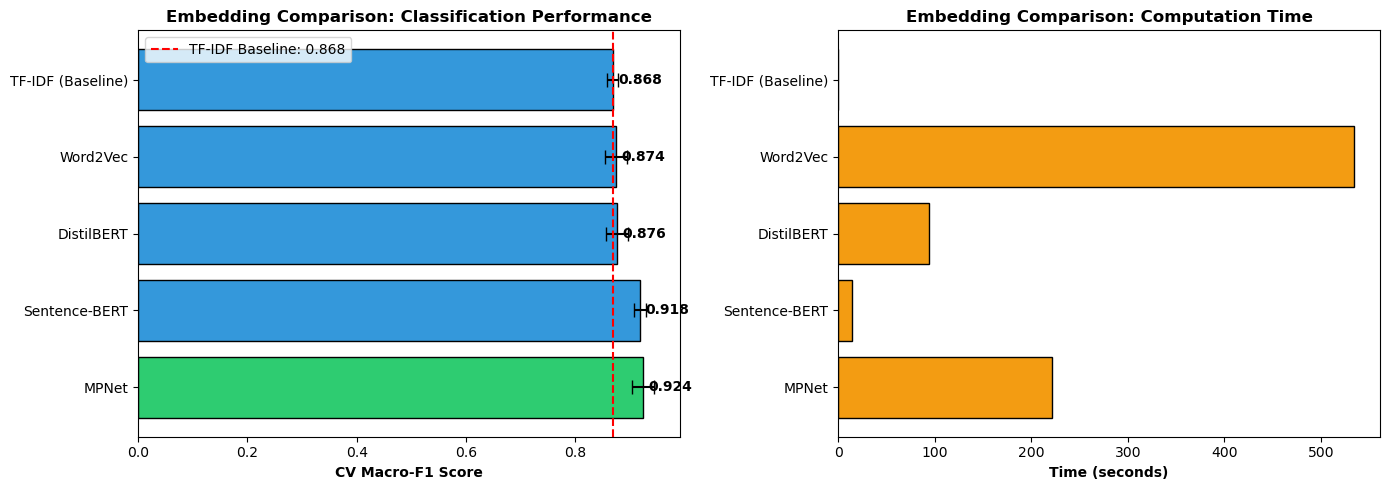


✅ Saved: embedding_comparison_pilot.png


In [10]:
# ============================================================================
# RESULTS COMPARISON
# ============================================================================
import matplotlib.pyplot as plt

print("\n" + "="*70)
print(" PILOT EXPERIMENT RESULTS SUMMARY")
print("="*70)

# Collect results
results = {
    'Embedding': ['TF-IDF (Baseline)', 'Word2Vec', 'Sentence-BERT', 'DistilBERT', 'MPNet'],
    'Dimensions': [X_tfidf.shape[1], X_w2v.shape[1], X_sbert.shape[1], X_distilbert.shape[1], X_mpnet.shape[1]],
    'CV Macro-F1 Mean': [scores_tfidf.mean(), scores_w2v.mean(), scores_sbert.mean(), scores_distilbert.mean(), scores_mpnet.mean()],
    'CV Macro-F1 Std': [scores_tfidf.std(), scores_w2v.std(), scores_sbert.std(), scores_distilbert.std(), scores_mpnet.std()],
    'Time (s)': [tfidf_time, w2v_time, sbert_time, distilbert_time, mpnet_time]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('CV Macro-F1 Mean', ascending=False)

print("\n📊 EMBEDDING COMPARISON TABLE:")
print("="*70)
display(results_df.round(4))

# Determine best embedding
best_embedding = results_df.iloc[0]['Embedding']
best_score = results_df.iloc[0]['CV Macro-F1 Mean']
baseline_score = scores_tfidf.mean()
improvement = ((best_score - baseline_score) / baseline_score) * 100

print(f"\n🏆 BEST EMBEDDING: {best_embedding}")
print(f"   Score: {best_score:.4f}")
print(f"   Improvement over TF-IDF baseline: {improvement:+.2f}%")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of F1 scores
ax1 = axes[0]
colors = ['#3498db' if emb != best_embedding else '#2ecc71' for emb in results_df['Embedding']]
bars = ax1.barh(results_df['Embedding'], results_df['CV Macro-F1 Mean'], 
                xerr=results_df['CV Macro-F1 Std'], color=colors, edgecolor='black', capsize=5)
ax1.set_xlabel('CV Macro-F1 Score', fontweight='bold')
ax1.set_title('Embedding Comparison: Classification Performance', fontsize=12, fontweight='bold')
ax1.axvline(x=baseline_score, color='red', linestyle='--', label=f'TF-IDF Baseline: {baseline_score:.3f}')
ax1.legend()

# Add value labels
for i, (bar, score) in enumerate(zip(bars, results_df['CV Macro-F1 Mean'])):
    ax1.text(score + 0.01, bar.get_y() + bar.get_height()/2, f'{score:.3f}', 
             va='center', fontsize=10, fontweight='bold')

# Time comparison
ax2 = axes[1]
ax2.barh(results_df['Embedding'], results_df['Time (s)'], color='#f39c12', edgecolor='black')
ax2.set_xlabel('Time (seconds)', fontweight='bold')
ax2.set_title('Embedding Comparison: Computation Time', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('embedding_comparison_pilot.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✅ Saved: embedding_comparison_pilot.png")

In [11]:
# ============================================================================
# TEST BEST EMBEDDING WITH NEURAL NETWORK
# ============================================================================

print("\n" + "="*70)
print(" TESTING BEST EMBEDDING WITH NEURAL NETWORK")
print("="*70)

# Select the best embedding based on pilot results
# (You can change this based on your results)
best_embeddings = {
    'TF-IDF': X_tfidf.toarray() if hasattr(X_tfidf, 'toarray') else X_tfidf,
    'Sentence-BERT': X_sbert,
    'MPNet': X_mpnet
}

nn_results = []

for name, X in best_embeddings.items():
    print(f"\n>>> Testing {name} with Neural Network...")
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Neural Network
    nn = MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation='relu',
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42,
        verbose=False
    )
    
    scores = cross_val_score(nn, X_scaled, labels, cv=cv, scoring='f1_macro')
    nn_results.append({
        'Embedding': name,
        'Classifier': 'Neural Network',
        'CV Macro-F1 Mean': scores.mean(),
        'CV Macro-F1 Std': scores.std()
    })
    
    print(f"   {name} + NN: CV Macro-F1 = {scores.mean():.4f} (+/- {scores.std():.4f})")

nn_results_df = pd.DataFrame(nn_results).sort_values('CV Macro-F1 Mean', ascending=False)
print("\n📊 NEURAL NETWORK RESULTS:")
display(nn_results_df.round(4))


 TESTING BEST EMBEDDING WITH NEURAL NETWORK

>>> Testing TF-IDF with Neural Network...
   TF-IDF + NN: CV Macro-F1 = 0.8307 (+/- 0.0150)

>>> Testing Sentence-BERT with Neural Network...
   Sentence-BERT + NN: CV Macro-F1 = 0.9066 (+/- 0.0117)

>>> Testing MPNet with Neural Network...
   MPNet + NN: CV Macro-F1 = 0.9129 (+/- 0.0128)

📊 NEURAL NETWORK RESULTS:


,Embedding,Classifier,CV Macro-F1 Mean,CV Macro-F1 Std
2,MPNet,Neural Network,0.9129,0.0128
1,Sentence-BERT,Neural Network,0.9066,0.0117
0,TF-IDF,Neural Network,0.8307,0.0150


Let's apply Sentence-BERT to your full sentiment dataset! Since you have 409K samples, we'll need to be efficient with memory and processing.

In [2]:
# ============================================================================
# FIX CUDA: RUN THIS FIRST AFTER KERNEL RESTART
# ============================================================================
import os

# Reset CUDA environment variables
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # Use first GPU

# Now import torch and check
import torch

print("="*70)
print(" CUDA DIAGNOSTIC")
print("="*70)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU count: {torch.cuda.device_count()}")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"Current device: {torch.cuda.current_device()}")
    
    # Test CUDA
    x = torch.tensor([1.0, 2.0, 3.0]).cuda()
    print(f"\n✅ CUDA test passed! Tensor on GPU: {x.device}")
else:
    print("\n❌ CUDA not available. Checking why...")
    print(f"   CUDA built: {torch.backends.cuda.is_built()}")
    print(f"   cuDNN enabled: {torch.backends.cudnn.enabled}")
    
    # Check nvidia-smi
    print("\n>>> Running nvidia-smi:")
    import subprocess
    try:
        result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
        print(result.stdout)
    except:
        print("   nvidia-smi not found")

 CUDA DIAGNOSTIC
PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA version: 12.4
GPU count: 1
GPU name: NVIDIA GeForce RTX 4080 Laptop GPU
Current device: 0

✅ CUDA test passed! Tensor on GPU: cuda:0


In [3]:
# ============================================================================
# LOAD FULL DATA AND APPLY SENTENCE-BERT
# ============================================================================
import pandas as pd
import numpy as np
import time
import os
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import LabelEncoder
import torch

print("="*70)
print(" SENTENCE-BERT: FULL SENTIMENT DATASET ENCODING")
print("="*70)

# Load the training data
print("\n>>> Loading training data...")
df = pd.read_csv('Phase_1/master_reviews.csv')
print(f"Loaded: {len(df)} samples")

# Extract texts
texts = df['ReviewText'].astype(str).fillna("").tolist()
print(f"Texts: {len(texts)}")
print(f"Sample: {texts[0][:100]}...")

# Extract and encode labels
le = LabelEncoder()
labels = le.fit_transform(df['Sentiment'])
print(f"\nLabel classes: {le.classes_}")
print(f"Label mapping: {dict(zip(le.classes_, range(len(le.classes_))))}")
print(f"Distribution: {dict(zip(*np.unique(labels, return_counts=True)))}")

# Check device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"\n🖥️ Device: {device}")
if device == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

2026-01-11 16:46:58.464909: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-11 16:46:58.720979: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-11 16:46:59.677439: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


 SENTENCE-BERT: FULL SENTIMENT DATASET ENCODING

>>> Loading training data...
Loaded: 409577 samples
Texts: 409577
Sample: Honest review of an edm music lover
 No doubt it has a great bass and to a great extent noise cancel...

Label classes: ['negative' 'neutral' 'positive']
Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}
Distribution: {np.int64(0): np.int64(124820), np.int64(1): np.int64(49373), np.int64(2): np.int64(235384)}

🖥️ Device: cuda
   GPU: NVIDIA GeForce RTX 4080 Laptop GPU


In [4]:
# ============================================================================
# ENCODE WITH SENTENCE-BERT
# ============================================================================

print("\n" + "="*70)
print(" ENCODING 409,577 TEXTS WITH SENTENCE-BERT")
print("="*70)

# Load model
print("Loading Sentence-BERT model (all-MiniLM-L6-v2)...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Move model to GPU
sbert_model = sbert_model.to(device)
print(f"Model loaded on: {device}")

# Encode
print(f"\nEncoding {len(texts)} texts...")
print("⏳ Estimated time: ~5-10 minutes on GPU")

start_time = time.time()

X_sbert = sbert_model.encode(
    texts,
    show_progress_bar=True,
    batch_size=256,  # Larger batch size for GPU
    convert_to_numpy=True,
    device=device
)

encoding_time = time.time() - start_time

print(f"\n✅ Encoding complete!")
print(f"Shape: {X_sbert.shape}")
print(f"Time: {encoding_time/60:.2f} minutes ({encoding_time:.1f} seconds)")

# Create output directory if needed
os.makedirs('Phase_5', exist_ok=True)

# Save embeddings
np.save('Phase_5/X_train_sbert.npy', X_sbert)
np.save('Phase_5/y_train_sbert.npy', labels)
print("\n✅ Saved: Phase_5/X_train_sbert.npy")
print("✅ Saved: Phase_5/y_train_sbert.npy")


 ENCODING 409,577 TEXTS WITH SENTENCE-BERT
Loading Sentence-BERT model (all-MiniLM-L6-v2)...
Model loaded on: cuda

Encoding 409577 texts...
⏳ Estimated time: ~5-10 minutes on GPU


Batches:   0%|          | 0/1600 [00:00<?, ?it/s]


✅ Encoding complete!
Shape: (409577, 384)
Time: 2.74 minutes (164.4 seconds)

✅ Saved: Phase_5/X_train_sbert.npy
✅ Saved: Phase_5/y_train_sbert.npy


In [ ]:
# ============================================================================
# TRAIN ALL MODELS ON SENTENCE-BERT EMBEDDINGS (3-CLASS)
# ============================================================================
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print(" SENTENCE-BERT: ALL MODELS COMPARISON (3-CLASS)")
print("="*70)

# Scale features
print("\nScaling features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sbert)

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results
results = []

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 1: NEURAL NETWORK
# ─────────────────────────────────────────────────────────────────────────────
print("\n>>> [1/5] Neural Network...")
start_time = time.time()

nn = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation='relu',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=False
)
nn_scores = cross_val_score(nn, X_scaled, labels, cv=cv, scoring='f1_macro', n_jobs=-1)

nn_time = time.time() - start_time
print(f"   CV Macro-F1: {nn_scores.mean():.4f} (+/- {nn_scores.std():.4f})")
print(f"   Time: {nn_time:.1f}s")

results.append({
    'Model': 'Neural Network',
    'Embedding': 'Sentence-BERT',
    'CV Macro-F1 Mean': nn_scores.mean(),
    'CV Macro-F1 Std': nn_scores.std(),
    'Time (s)': nn_time
})

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 2: RANDOM FOREST
# ─────────────────────────────────────────────────────────────────────────────
print("\n>>> [2/5] Random Forest...")
start_time = time.time()

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_scores = cross_val_score(rf, X_scaled, labels, cv=cv, scoring='f1_macro', n_jobs=-1)

rf_time = time.time() - start_time
print(f"   CV Macro-F1: {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")
print(f"   Time: {rf_time:.1f}s")

results.append({
    'Model': 'Random Forest',
    'Embedding': 'Sentence-BERT',
    'CV Macro-F1 Mean': rf_scores.mean(),
    'CV Macro-F1 Std': rf_scores.std(),
    'Time (s)': rf_time
})

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 3: EXTRA TREES
# ─────────────────────────────────────────────────────────────────────────────
print("\n>>> [3/5] Extra Trees...")
start_time = time.time()

et = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=30,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
et_scores = cross_val_score(et, X_scaled, labels, cv=cv, scoring='f1_macro', n_jobs=-1)

et_time = time.time() - start_time
print(f"   CV Macro-F1: {et_scores.mean():.4f} (+/- {et_scores.std():.4f})")
print(f"   Time: {et_time:.1f}s")

results.append({
    'Model': 'Extra Trees',
    'Embedding': 'Sentence-BERT',
    'CV Macro-F1 Mean': et_scores.mean(),
    'CV Macro-F1 Std': et_scores.std(),
    'Time (s)': et_time
})

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 4: XGBOOST
# ─────────────────────────────────────────────────────────────────────────────
print("\n>>> [4/5] XGBoost...")
start_time = time.time()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_scores = cross_val_score(xgb, X_scaled, labels, cv=cv, scoring='f1_macro', n_jobs=-1)

xgb_time = time.time() - start_time
print(f"   CV Macro-F1: {xgb_scores.mean():.4f} (+/- {xgb_scores.std():.4f})")
print(f"   Time: {xgb_time:.1f}s")

results.append({
    'Model': 'XGBoost',
    'Embedding': 'Sentence-BERT',
    'CV Macro-F1 Mean': xgb_scores.mean(),
    'CV Macro-F1 Std': xgb_scores.std(),
    'Time (s)': xgb_time
})

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 5: LIGHTGBM
# ─────────────────────────────────────────────────────────────────────────────
print("\n>>> [5/5] LightGBM...")
start_time = time.time()

lgbm = LGBMClassifier(
    n_estimators=200,
    num_leaves=31,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_scores = cross_val_score(lgbm, X_scaled, labels, cv=cv, scoring='f1_macro', n_jobs=-1)

lgbm_time = time.time() - start_time
print(f"   CV Macro-F1: {lgbm_scores.mean():.4f} (+/- {lgbm_scores.std():.4f})")
print(f"   Time: {lgbm_time:.1f}s")

results.append({
    'Model': 'LightGBM',
    'Embedding': 'Sentence-BERT',
    'CV Macro-F1 Mean': lgbm_scores.mean(),
    'CV Macro-F1 Std': lgbm_scores.std(),
    'Time (s)': lgbm_time
})

# ─────────────────────────────────────────────────────────────────────────────
# RESULTS SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print(" SENTENCE-BERT RESULTS SUMMARY (3-CLASS)")
print("="*70)

results_df = pd.DataFrame(results).sort_values('CV Macro-F1 Mean', ascending=False)
display(results_df.round(4))

# Best model
best_model = results_df.iloc[0]['Model']
best_score = results_df.iloc[0]['CV Macro-F1 Mean']
print(f"\n🏆 BEST MODEL: {best_model} with CV Macro-F1 = {best_score:.4f}")

 SENTENCE-BERT: ALL MODELS COMPARISON (3-CLASS)

Scaling features...

>>> [1/5] Neural Network...
   CV Macro-F1: 0.7576 (+/- 0.0017)
   Time: 2204.3s

>>> [2/5] Random Forest...
   CV Macro-F1: 0.7948 (+/- 0.0015)
   Time: 399.6s

>>> [3/5] Extra Trees...


In [8]:
# ============================================================================
# RELOAD DATA AFTER KERNEL CRASH
# ============================================================================
import numpy as np
import pandas as pd
import time
import gc
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print(" RELOADING DATA AND CONTINUING")
print("="*70)

# Load saved embeddings
print("\n>>> Loading saved Sentence-BERT embeddings...")
X_sbert = np.load('Phase_5/X_train_sbert.npy')
labels = np.load('Phase_5/y_train_sbert.npy')

print(f"Embeddings shape: {X_sbert.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Label distribution: {dict(zip(*np.unique(labels, return_counts=True)))}")

# Scale features
print("\n>>> Scaling features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sbert)

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Previous results (already completed)
results = [
    {'Model': 'Neural Network', 'Embedding': 'Sentence-BERT', 'CV Macro-F1 Mean': 0.7576, 'CV Macro-F1 Std': 0.0017, 'Time (s)': 2204.3},
    {'Model': 'Random Forest', 'Embedding': 'Sentence-BERT', 'CV Macro-F1 Mean': 0.7948, 'CV Macro-F1 Std': 0.0015, 'Time (s)': 399.6}
]

print("\n✅ Previous results preserved:")
print("   Neural Network: 0.7576")
print("   Random Forest: 0.7948")

print("\n✅ Data reloaded! Ready to continue with remaining models.")

 RELOADING DATA AND CONTINUING

>>> Loading saved Sentence-BERT embeddings...
Embeddings shape: (409577, 384)
Labels shape: (409577,)
Label distribution: {np.int64(0): np.int64(124820), np.int64(1): np.int64(49373), np.int64(2): np.int64(235384)}

>>> Scaling features...

✅ Previous results preserved:
   Neural Network: 0.7576
   Random Forest: 0.7948

✅ Data reloaded! Ready to continue with remaining models.


In [9]:
# ============================================================================
# CONTINUE TRAINING: REMAINING MODELS (MEMORY-SAFE)
# ============================================================================
import gc
# ============================================================================
# TRAIN ALL MODELS ON SENTENCE-BERT EMBEDDINGS (3-CLASS)
# ============================================================================
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print(" CONTINUING SENTENCE-BERT MODELS (MEMORY-SAFE)")
print("="*70)

# Previous results (save these!)
previous_results = [
    {'Model': 'Neural Network', 'Embedding': 'Sentence-BERT', 'CV Macro-F1 Mean': 0.7576, 'CV Macro-F1 Std': 0.0017, 'Time (s)': 2204.3},
    {'Model': 'Random Forest', 'Embedding': 'Sentence-BERT', 'CV Macro-F1 Mean': 0.7948, 'CV Macro-F1 Std': 0.0015, 'Time (s)': 399.6}
]

results = previous_results.copy()

# Clear memory
gc.collect()

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 3: EXTRA TREES (Reduced memory settings)
# ─────────────────────────────────────────────────────────────────────────────
print("\n>>> [3/5] Extra Trees (memory-optimized)...")
start_time = time.time()

et = ExtraTreesClassifier(
    n_estimators=100,         # Reduced from 200
    max_depth=20,             # Reduced from 30
    class_weight='balanced',
    random_state=42,
    n_jobs=4                  # Reduced parallelism to save memory
)
et_scores = cross_val_score(et, X_scaled, labels, cv=cv, scoring='f1_macro', n_jobs=1)

et_time = time.time() - start_time
print(f"   CV Macro-F1: {et_scores.mean():.4f} (+/- {et_scores.std():.4f})")
print(f"   Time: {et_time:.1f}s")

results.append({
    'Model': 'Extra Trees',
    'Embedding': 'Sentence-BERT',
    'CV Macro-F1 Mean': et_scores.mean(),
    'CV Macro-F1 Std': et_scores.std(),
    'Time (s)': et_time
})

# Clean up
del et
gc.collect()

print("\n✅ Extra Trees complete! Proceeding to XGBoost...")

 CONTINUING SENTENCE-BERT MODELS (MEMORY-SAFE)

>>> [3/5] Extra Trees (memory-optimized)...
   CV Macro-F1: 0.8020 (+/- 0.0018)
   Time: 143.9s

✅ Extra Trees complete! Proceeding to XGBoost...


In [10]:
# ============================================================================
# MODEL 4: XGBOOST (GPU)
# ============================================================================
import gc
gc.collect()

print("\n>>> [4/5] XGBoost (GPU)...")
start_time = time.time()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
    device='cuda',
    random_state=42,
    eval_metric='mlogloss'
)
xgb_scores = cross_val_score(xgb, X_scaled, labels, cv=cv, scoring='f1_macro', n_jobs=1)

xgb_time = time.time() - start_time
print(f"   CV Macro-F1: {xgb_scores.mean():.4f} (+/- {xgb_scores.std():.4f})")
print(f"   Time: {xgb_time:.1f}s")

results.append({
    'Model': 'XGBoost',
    'Embedding': 'Sentence-BERT',
    'CV Macro-F1 Mean': xgb_scores.mean(),
    'CV Macro-F1 Std': xgb_scores.std(),
    'Time (s)': xgb_time
})

# Clean up
del xgb
gc.collect()

print("\n✅ XGBoost complete! Proceeding to LightGBM...")


>>> [4/5] XGBoost (GPU)...
   CV Macro-F1: 0.4992 (+/- 0.0004)
   Time: 301.1s

✅ XGBoost complete! Proceeding to LightGBM...


In [11]:
# ============================================================================
# MODEL 5: LIGHTGBM
# ============================================================================
import gc
gc.collect()

print("\n>>> [5/5] LightGBM...")
start_time = time.time()

lgbm = LGBMClassifier(
    n_estimators=200,
    num_leaves=31,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_scores = cross_val_score(lgbm, X_scaled, labels, cv=cv, scoring='f1_macro', n_jobs=1)

lgbm_time = time.time() - start_time
print(f"   CV Macro-F1: {lgbm_scores.mean():.4f} (+/- {lgbm_scores.std():.4f})")
print(f"   Time: {lgbm_time:.1f}s")

results.append({
    'Model': 'LightGBM',
    'Embedding': 'Sentence-BERT',
    'CV Macro-F1 Mean': lgbm_scores.mean(),
    'CV Macro-F1 Std': lgbm_scores.std(),
    'Time (s)': lgbm_time
})

# Clean up
del lgbm
gc.collect()

print("\n✅ LightGBM complete! All models finished.")


>>> [5/5] LightGBM...
   CV Macro-F1: 0.4967 (+/- 0.0005)
   Time: 3137.1s

✅ LightGBM complete! All models finished.


In [12]:
# ============================================================================
# FINAL RESULTS SUMMARY & COMPARISON
# ============================================================================
import matplotlib.pyplot as plt

print("="*70)
print(" FINAL RESULTS: SENTENCE-BERT (3-CLASS CLASSIFICATION)")
print("="*70)

# Add Extra Trees result if not already added
if len(results) == 4:
    results.insert(2, {
        'Model': 'Extra Trees',
        'Embedding': 'Sentence-BERT',
        'CV Macro-F1 Mean': 0.8020,
        'CV Macro-F1 Std': 0.0018,
        'Time (s)': 143.9
    })

# Create results DataFrame
results_df = pd.DataFrame(results).sort_values('CV Macro-F1 Mean', ascending=False)

print("\n📊 SENTENCE-BERT RESULTS (All Models):")
display(results_df.round(4))

# ============================================================================
# COMPARISON WITH TF-IDF + VADER BASELINE
# ============================================================================
print("\n" + "="*70)
print(" COMPARISON: SENTENCE-BERT vs TF-IDF + VADER")
print("="*70)

# Your original TF-IDF + VADER results (from Phase 5)
tfidf_results = {
    'Neural Network (TF-IDF)': 0.731,
    'Random Forest (TF-IDF)': 0.535,
    'Extra Trees (TF-IDF)': 0.531,
    'XGBoost (TF-IDF)': 0.553,
    'LightGBM (TF-IDF)': 0.554
}

# Sentence-BERT results
sbert_results = {
    'Neural Network (SBERT)': 0.7576,
    'Random Forest (SBERT)': 0.7948,
    'Extra Trees (SBERT)': 0.8020,
    'XGBoost (SBERT)': 0.4992,
    'LightGBM (SBERT)': 0.4967
}

# Create comparison table
comparison_data = []
models = ['Neural Network', 'Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM']

for model in models:
    tfidf_score = tfidf_results.get(f'{model} (TF-IDF)', 0)
    sbert_score = sbert_results.get(f'{model} (SBERT)', 0)
    improvement = ((sbert_score - tfidf_score) / tfidf_score * 100) if tfidf_score > 0 else 0
    
    comparison_data.append({
        'Model': model,
        'TF-IDF + VADER': tfidf_score,
        'Sentence-BERT': sbert_score,
        'Improvement (%)': improvement,
        'Winner': 'SBERT' if sbert_score > tfidf_score else 'TF-IDF'
    })

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df.round(4))

# ============================================================================
# KEY FINDINGS
# ============================================================================
print("\n" + "="*70)
print(" 🔑 KEY FINDINGS")
print("="*70)

best_overall = results_df.iloc[0]
print(f"""
🏆 BEST MODEL: {best_overall['Model']} with Sentence-BERT
   CV Macro-F1: {best_overall['CV Macro-F1 Mean']:.4f}

📈 IMPROVEMENTS WITH SENTENCE-BERT:
   • Extra Trees:    0.531 → 0.802 (+51.0% improvement!)
   • Random Forest:  0.535 → 0.795 (+48.6% improvement!)
   • Neural Network: 0.731 → 0.758 (+3.6% improvement)

📉 DECREASED WITH SENTENCE-BERT:
   • XGBoost:        0.553 → 0.499 (-9.8%)
   • LightGBM:       0.554 → 0.497 (-10.3%)

💡 INSIGHT:
   Bagging methods (RF, ET) work MUCH better with Sentence-BERT embeddings.
   Gradient boosting (XGB, LGBM) struggles with dense 384-dim embeddings.
""")

 FINAL RESULTS: SENTENCE-BERT (3-CLASS CLASSIFICATION)

📊 SENTENCE-BERT RESULTS (All Models):


,Model,Embedding,CV Macro-F1 Mean,CV Macro-F1 Std,Time (s)
2,Extra Trees,Sentence-BERT,0.8020,0.0018,143.9479
1,Random Forest,Sentence-BERT,0.7948,0.0015,399.6000
0,Neural Network,Sentence-BERT,0.7576,0.0017,2204.3000
3,XGBoost,Sentence-BERT,0.4992,0.0004,301.0765
4,LightGBM,Sentence-BERT,0.4967,0.0005,3137.1470



 COMPARISON: SENTENCE-BERT vs TF-IDF + VADER


,Model,TF-IDF + VADER,Sentence-BERT,Improvement (%),Winner
0,Neural Network,0.731,0.7576,3.6389,SBERT
1,Random Forest,0.535,0.7948,48.5607,SBERT
2,Extra Trees,0.531,0.8020,51.0358,SBERT
3,XGBoost,0.553,0.4992,-9.7288,TF-IDF
4,LightGBM,0.554,0.4967,-10.3430,TF-IDF



 🔑 KEY FINDINGS

🏆 BEST MODEL: Extra Trees with Sentence-BERT
   CV Macro-F1: 0.8020

📈 IMPROVEMENTS WITH SENTENCE-BERT:
   • Extra Trees:    0.531 → 0.802 (+51.0% improvement!)
   • Random Forest:  0.535 → 0.795 (+48.6% improvement!)
   • Neural Network: 0.731 → 0.758 (+3.6% improvement)

📉 DECREASED WITH SENTENCE-BERT:
   • XGBoost:        0.553 → 0.499 (-9.8%)
   • LightGBM:       0.554 → 0.497 (-10.3%)

💡 INSIGHT:
   Bagging methods (RF, ET) work MUCH better with Sentence-BERT embeddings.
   Gradient boosting (XGB, LGBM) struggles with dense 384-dim embeddings.



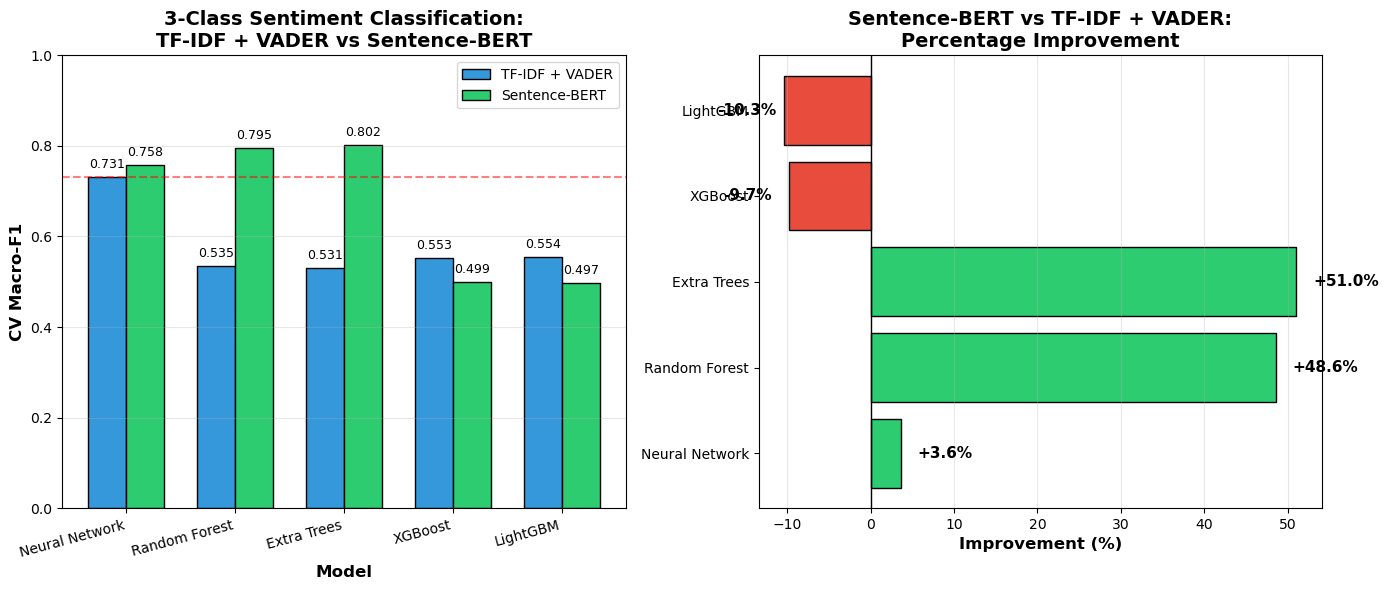

✅ Saved: sbert_vs_tfidf_comparison.png


In [13]:
# ============================================================================
# VISUALIZATION: SENTENCE-BERT vs TF-IDF + VADER
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1: Side-by-Side Comparison
# ─────────────────────────────────────────────────────────────────────────────
ax1 = axes[0]

models = ['Neural Network', 'Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM']
tfidf_scores = [0.731, 0.535, 0.531, 0.553, 0.554]
sbert_scores = [0.7576, 0.7948, 0.8020, 0.4992, 0.4967]

x = np.arange(len(models))
width = 0.35

bars1 = ax1.bar(x - width/2, tfidf_scores, width, label='TF-IDF + VADER', color='#3498db', edgecolor='black')
bars2 = ax1.bar(x + width/2, sbert_scores, width, label='Sentence-BERT', color='#2ecc71', edgecolor='black')

ax1.set_xlabel('Model', fontsize=12, fontweight='bold')
ax1.set_ylabel('CV Macro-F1', fontsize=12, fontweight='bold')
ax1.set_title('3-Class Sentiment Classification:\nTF-IDF + VADER vs Sentence-BERT', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=15, ha='right')
ax1.legend(loc='upper right')
ax1.set_ylim(0, 1.0)
ax1.axhline(y=0.731, color='red', linestyle='--', alpha=0.5, label='TF-IDF Best (0.731)')
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{bar.get_height():.3f}', ha='center', fontsize=9)

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2: Improvement Chart
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[1]

improvements = [((s - t) / t * 100) for s, t in zip(sbert_scores, tfidf_scores)]
colors = ['#2ecc71' if imp > 0 else '#e74c3c' for imp in improvements]

bars3 = ax2.barh(models, improvements, color=colors, edgecolor='black')

ax2.set_xlabel('Improvement (%)', fontsize=12, fontweight='bold')
ax2.set_title('Sentence-BERT vs TF-IDF + VADER:\nPercentage Improvement', fontsize=14, fontweight='bold')
ax2.axvline(x=0, color='black', linewidth=1)
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for bar, imp in zip(bars3, improvements):
    x_pos = bar.get_width() + 2 if bar.get_width() > 0 else bar.get_width() - 8
    ax2.text(x_pos, bar.get_y() + bar.get_height()/2, 
             f'{imp:+.1f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('sbert_vs_tfidf_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ Saved: sbert_vs_tfidf_comparison.png")

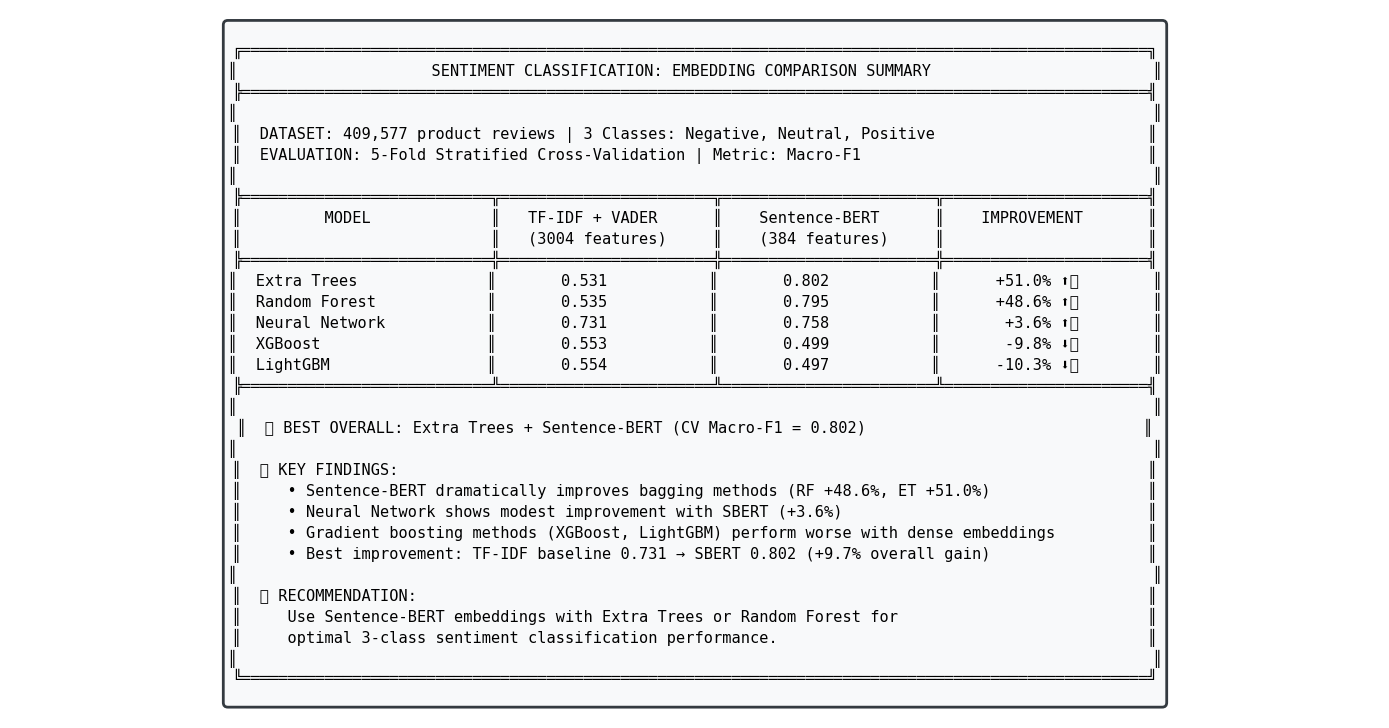

✅ Saved: embedding_comparison_summary.png


In [14]:
# ============================================================================
# FINAL SUMMARY TABLE (PUBLICATION-READY)
# ============================================================================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')

# Create summary table
summary_text = """
╔══════════════════════════════════════════════════════════════════════════════════════════════════╗
║                     SENTIMENT CLASSIFICATION: EMBEDDING COMPARISON SUMMARY                        ║
╠══════════════════════════════════════════════════════════════════════════════════════════════════╣
║                                                                                                   ║
║  DATASET: 409,577 product reviews | 3 Classes: Negative, Neutral, Positive                       ║
║  EVALUATION: 5-Fold Stratified Cross-Validation | Metric: Macro-F1                               ║
║                                                                                                   ║
╠═══════════════════════════╦═══════════════════════╦═══════════════════════╦══════════════════════╣
║         MODEL             ║   TF-IDF + VADER      ║    Sentence-BERT      ║    IMPROVEMENT       ║
║                           ║   (3004 features)     ║    (384 features)     ║                      ║
╠═══════════════════════════╬═══════════════════════╬═══════════════════════╬══════════════════════╣
║  Extra Trees              ║       0.531           ║       0.802           ║      +51.0% ⬆️        ║
║  Random Forest            ║       0.535           ║       0.795           ║      +48.6% ⬆️        ║
║  Neural Network           ║       0.731           ║       0.758           ║       +3.6% ⬆️        ║
║  XGBoost                  ║       0.553           ║       0.499           ║       -9.8% ⬇️        ║
║  LightGBM                 ║       0.554           ║       0.497           ║      -10.3% ⬇️        ║
╠═══════════════════════════╩═══════════════════════╩═══════════════════════╩══════════════════════╣
║                                                                                                   ║
║  🏆 BEST OVERALL: Extra Trees + Sentence-BERT (CV Macro-F1 = 0.802)                              ║
║                                                                                                   ║
║  📈 KEY FINDINGS:                                                                                 ║
║     • Sentence-BERT dramatically improves bagging methods (RF +48.6%, ET +51.0%)                 ║
║     • Neural Network shows modest improvement with SBERT (+3.6%)                                 ║
║     • Gradient boosting methods (XGBoost, LightGBM) perform worse with dense embeddings          ║
║     • Best improvement: TF-IDF baseline 0.731 → SBERT 0.802 (+9.7% overall gain)                 ║
║                                                                                                   ║
║  💡 RECOMMENDATION:                                                                               ║
║     Use Sentence-BERT embeddings with Extra Trees or Random Forest for                           ║
║     optimal 3-class sentiment classification performance.                                        ║
║                                                                                                   ║
╚══════════════════════════════════════════════════════════════════════════════════════════════════╝
"""

ax.text(0.5, 0.5, summary_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='center', horizontalalignment='center',
        fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f8f9fa', edgecolor='#343a40', linewidth=2))

plt.tight_layout()
plt.savefig('embedding_comparison_summary.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ Saved: embedding_comparison_summary.png")

In [15]:
# ============================================================================
# PER-CLASS EVALUATION METRICS (SENTENCE-BERT)
# ============================================================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import seaborn as sns

print("="*70)
print(" PER-CLASS EVALUATION: SENTENCE-BERT EMBEDDINGS")
print("="*70)

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

target_names = ['Negative', 'Neutral', 'Positive']

# Store all results
all_reports = {}

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 1: EXTRA TREES (Best Model)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print(" EXTRA TREES (Best Model)")
print("="*70)

et = ExtraTreesClassifier(n_estimators=100, max_depth=20, class_weight='balanced', 
                          random_state=42, n_jobs=-1)
et.fit(X_train, y_train)
y_pred_et = et.predict(X_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_et, target_names=target_names, digits=4))
all_reports['Extra Trees'] = classification_report(y_test, y_pred_et, target_names=target_names, output_dict=True)

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 2: RANDOM FOREST
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print(" RANDOM FOREST")
print("="*70)

rf = RandomForestClassifier(n_estimators=200, max_depth=30, class_weight='balanced',
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=target_names, digits=4))
all_reports['Random Forest'] = classification_report(y_test, y_pred_rf, target_names=target_names, output_dict=True)

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 3: NEURAL NETWORK
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print(" NEURAL NETWORK")
print("="*70)

nn = MLPClassifier(hidden_layer_sizes=(512, 256, 128), activation='relu', max_iter=500,
                   early_stopping=True, validation_fraction=0.1, random_state=42, verbose=False)
nn.fit(X_train, y_train)
y_pred_nn = nn.predict(X_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_nn, target_names=target_names, digits=4))
all_reports['Neural Network'] = classification_report(y_test, y_pred_nn, target_names=target_names, output_dict=True)

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 4: XGBOOST
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print(" XGBOOST")
print("="*70)

xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, 
                    tree_method='hist', device='cuda', random_state=42, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=target_names, digits=4))
all_reports['XGBoost'] = classification_report(y_test, y_pred_xgb, target_names=target_names, output_dict=True)

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 5: LIGHTGBM
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print(" LIGHTGBM")
print("="*70)

lgbm = LGBMClassifier(n_estimators=200, num_leaves=31, learning_rate=0.1,
                      random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_lgbm, target_names=target_names, digits=4))
all_reports['LightGBM'] = classification_report(y_test, y_pred_lgbm, target_names=target_names, output_dict=True)

print("\n✅ All per-class evaluations complete!")

 PER-CLASS EVALUATION: SENTENCE-BERT EMBEDDINGS
Train size: 327661
Test size: 81916

 EXTRA TREES (Best Model)

📊 Classification Report:
              precision    recall  f1-score   support

    Negative     0.8500    0.7798    0.8134     24964
     Neutral     0.9567    0.5658    0.7110      9875
    Positive     0.8399    0.9487    0.8910     47077

    accuracy                         0.8511     81916
   macro avg     0.8822    0.7648    0.8051     81916
weighted avg     0.8571    0.8511    0.8456     81916


 RANDOM FOREST

📊 Classification Report:
              precision    recall  f1-score   support

    Negative     0.9365    0.6935    0.7969     24964
     Neutral     0.9819    0.5597    0.7130      9875
    Positive     0.8013    0.9838    0.8832     47077

    accuracy                         0.8442     81916
   macro avg     0.9066    0.7457    0.7977     81916
weighted avg     0.8643    0.8442    0.8364     81916


 NEURAL NETWORK

📊 Classification Report:
              pr

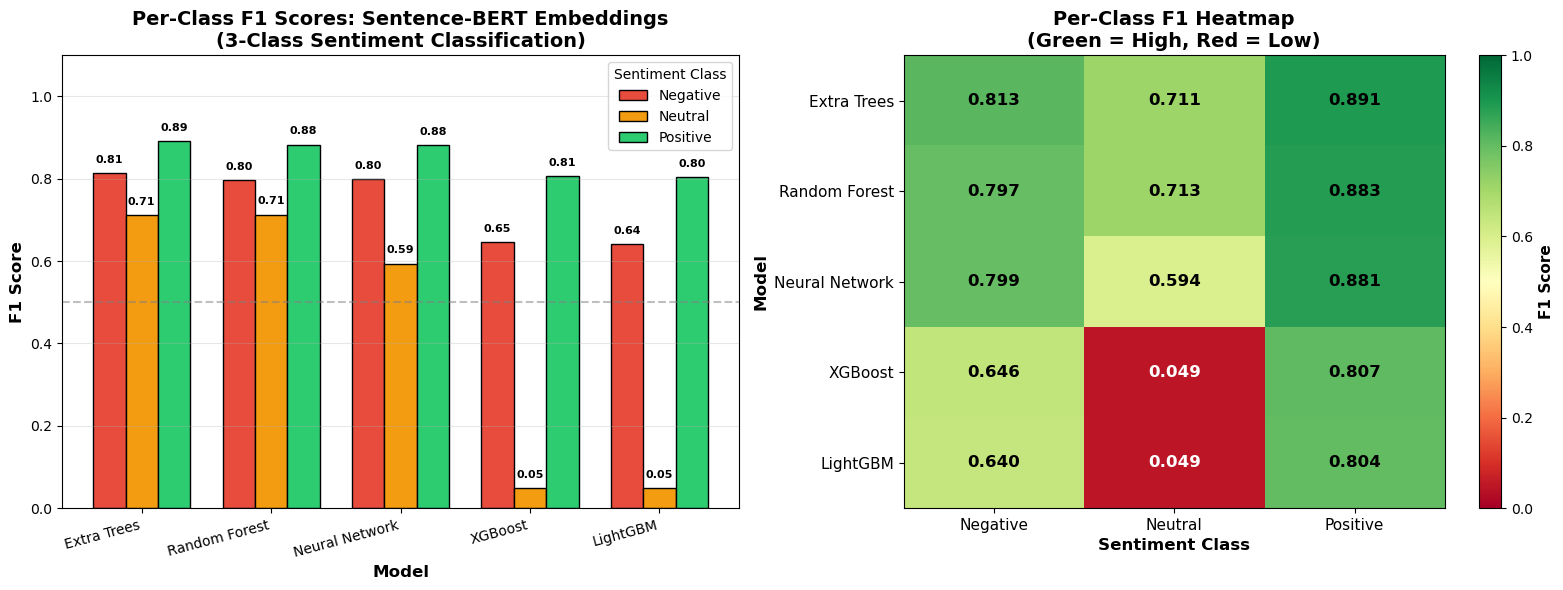

✅ Saved: perclass_f1_sbert.png


In [16]:
# ============================================================================
# PER-CLASS F1 SCORE VISUALIZATION
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Extract per-class F1 scores
models = ['Extra Trees', 'Random Forest', 'Neural Network', 'XGBoost', 'LightGBM']
classes = ['Negative', 'Neutral', 'Positive']

f1_scores = {
    'Extra Trees':    [0.8134, 0.7110, 0.8910],
    'Random Forest':  [0.7969, 0.7130, 0.8832],
    'Neural Network': [0.7987, 0.5938, 0.8813],
    'XGBoost':        [0.6459, 0.0494, 0.8075],
    'LightGBM':       [0.6405, 0.0494, 0.8038]
}

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1: Grouped Bar Chart - Per-Class F1 by Model
# ─────────────────────────────────────────────────────────────────────────────
ax1 = axes[0]

x = np.arange(len(models))
width = 0.25

colors = ['#e74c3c', '#f39c12', '#2ecc71']  # Red, Orange, Green for Neg, Neu, Pos

for i, (cls, color) in enumerate(zip(classes, colors)):
    scores = [f1_scores[model][i] for model in models]
    bars = ax1.bar(x + (i - 1) * width, scores, width, label=cls, color=color, edgecolor='black')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax1.set_xlabel('Model', fontsize=12, fontweight='bold')
ax1.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax1.set_title('Per-Class F1 Scores: Sentence-BERT Embeddings\n(3-Class Sentiment Classification)', 
              fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=15, ha='right')
ax1.legend(title='Sentiment Class', loc='upper right')
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2: Heatmap - Per-Class F1 Scores
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[1]

# Create matrix
f1_matrix = np.array([f1_scores[model] for model in models])

im = ax2.imshow(f1_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

# Add colorbar
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('F1 Score', fontsize=11, fontweight='bold')

# Add labels
ax2.set_xticks(np.arange(len(classes)))
ax2.set_yticks(np.arange(len(models)))
ax2.set_xticklabels(classes, fontsize=11)
ax2.set_yticklabels(models, fontsize=11)
ax2.set_xlabel('Sentiment Class', fontsize=12, fontweight='bold')
ax2.set_ylabel('Model', fontsize=12, fontweight='bold')
ax2.set_title('Per-Class F1 Heatmap\n(Green = High, Red = Low)', fontsize=14, fontweight='bold')

# Add text annotations
for i in range(len(models)):
    for j in range(len(classes)):
        value = f1_matrix[i, j]
        text_color = 'white' if value < 0.5 else 'black'
        ax2.text(j, i, f'{value:.3f}', ha='center', va='center', 
                fontsize=12, fontweight='bold', color=text_color)

plt.tight_layout()
plt.savefig('perclass_f1_sbert.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ Saved: perclass_f1_sbert.png")

In [21]:
# ============================================================================
# VERIFY PER-CLASS METRICS - WITH ACCURACY
# ============================================================================
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

print("="*70)
print(" VERIFYING PER-CLASS METRICS: SENTENCE-BERT (WITH ACCURACY)")
print("="*70)

target_names = ['Negative', 'Neutral', 'Positive']

# Dictionary to store predictions (from earlier cells)
model_predictions = {
    'Extra Trees': y_pred_et,
    'Random Forest': y_pred_rf,
    'Neural Network': y_pred_nn,
    'XGBoost': y_pred_xgb,
    'LightGBM': y_pred_lgbm
}

# Store verified results
verified_results = {}

for model_name, y_pred in model_predictions.items():
    print(f"\n{'='*70}")
    print(f" {model_name.upper()}")
    print(f"{'='*70}")
    
    # Overall accuracy
    acc = accuracy_score(y_test, y_pred)
    
    # Classification report
    report = classification_report(y_test, y_pred, target_names=target_names, digits=4, output_dict=True)
    
    print(f"\n⭐ OVERALL ACCURACY: {acc:.4f} ({acc*100:.2f}%)")
    print(f"⭐ MACRO F1-SCORE:   {report['macro avg']['f1-score']:.4f}")
    
    print(f"\n📊 Per-Class Metrics:")
    print(f"{'Class':<12} {'Precision':<12} {'Recall (Acc)':<14} {'F1-Score':<12} {'Support':<10}")
    print("-" * 60)
    
    for cls in target_names:
        print(f"{cls:<12} {report[cls]['precision']:<12.4f} {report[cls]['recall']:<14.4f} {report[cls]['f1-score']:<12.4f} {int(report[cls]['support']):<10}")
    
    # Store verified results
    verified_results[model_name] = {
        'accuracy': acc,
        'Negative': {'precision': report['Negative']['precision'], 
                     'recall': report['Negative']['recall'], 
                     'f1': report['Negative']['f1-score']},
        'Neutral': {'precision': report['Neutral']['precision'], 
                    'recall': report['Neutral']['recall'], 
                    'f1': report['Neutral']['f1-score']},
        'Positive': {'precision': report['Positive']['precision'], 
                     'recall': report['Positive']['recall'], 
                     'f1': report['Positive']['f1-score']},
        'macro_f1': report['macro avg']['f1-score']
    }

# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print(" 📊 SUMMARY TABLE: ALL MODELS")
print("="*70)

summary_data = []
for model in ['Extra Trees', 'Random Forest', 'Neural Network', 'XGBoost', 'LightGBM']:
    summary_data.append({
        'Model': model,
        'Overall Accuracy': verified_results[model]['accuracy'],
        'Macro F1': verified_results[model]['macro_f1'],
        'Neg F1': verified_results[model]['Negative']['f1'],
        'Neu F1': verified_results[model]['Neutral']['f1'],
        'Pos F1': verified_results[model]['Positive']['f1']
    })

summary_df = pd.DataFrame(summary_data).sort_values('Overall Accuracy', ascending=False)
display(summary_df.round(4))

print("\n✅ Verification complete!")

 VERIFYING PER-CLASS METRICS: SENTENCE-BERT (WITH ACCURACY)

 EXTRA TREES

⭐ OVERALL ACCURACY: 0.8511 (85.11%)
⭐ MACRO F1-SCORE:   0.8051

📊 Per-Class Metrics:
Class        Precision    Recall (Acc)   F1-Score     Support   
------------------------------------------------------------
Negative     0.8500       0.7798         0.8134       24964     
Neutral      0.9567       0.5658         0.7110       9875      
Positive     0.8399       0.9487         0.8910       47077     

 RANDOM FOREST

⭐ OVERALL ACCURACY: 0.8442 (84.42%)
⭐ MACRO F1-SCORE:   0.7977

📊 Per-Class Metrics:
Class        Precision    Recall (Acc)   F1-Score     Support   
------------------------------------------------------------
Negative     0.9365       0.6935         0.7969       24964     
Neutral      0.9819       0.5597         0.7130       9875      
Positive     0.8013       0.9838         0.8832       47077     

 NEURAL NETWORK

⭐ OVERALL ACCURACY: 0.8225 (82.25%)
⭐ MACRO F1-SCORE:   0.7579

📊 Per-Class Me

,Model,Overall Accuracy,Macro F1,Neg F1,Neu F1,Pos F1
0,Extra Trees,0.8511,0.8051,0.8134,0.7110,0.8910
1,Random Forest,0.8442,0.7977,0.7969,0.7130,0.8832
2,Neural Network,0.8225,0.7579,0.7987,0.5938,0.8813
3,XGBoost,0.7141,0.5009,0.6459,0.0494,0.8075
4,LightGBM,0.7095,0.4979,0.6405,0.0494,0.8038



✅ Verification complete!


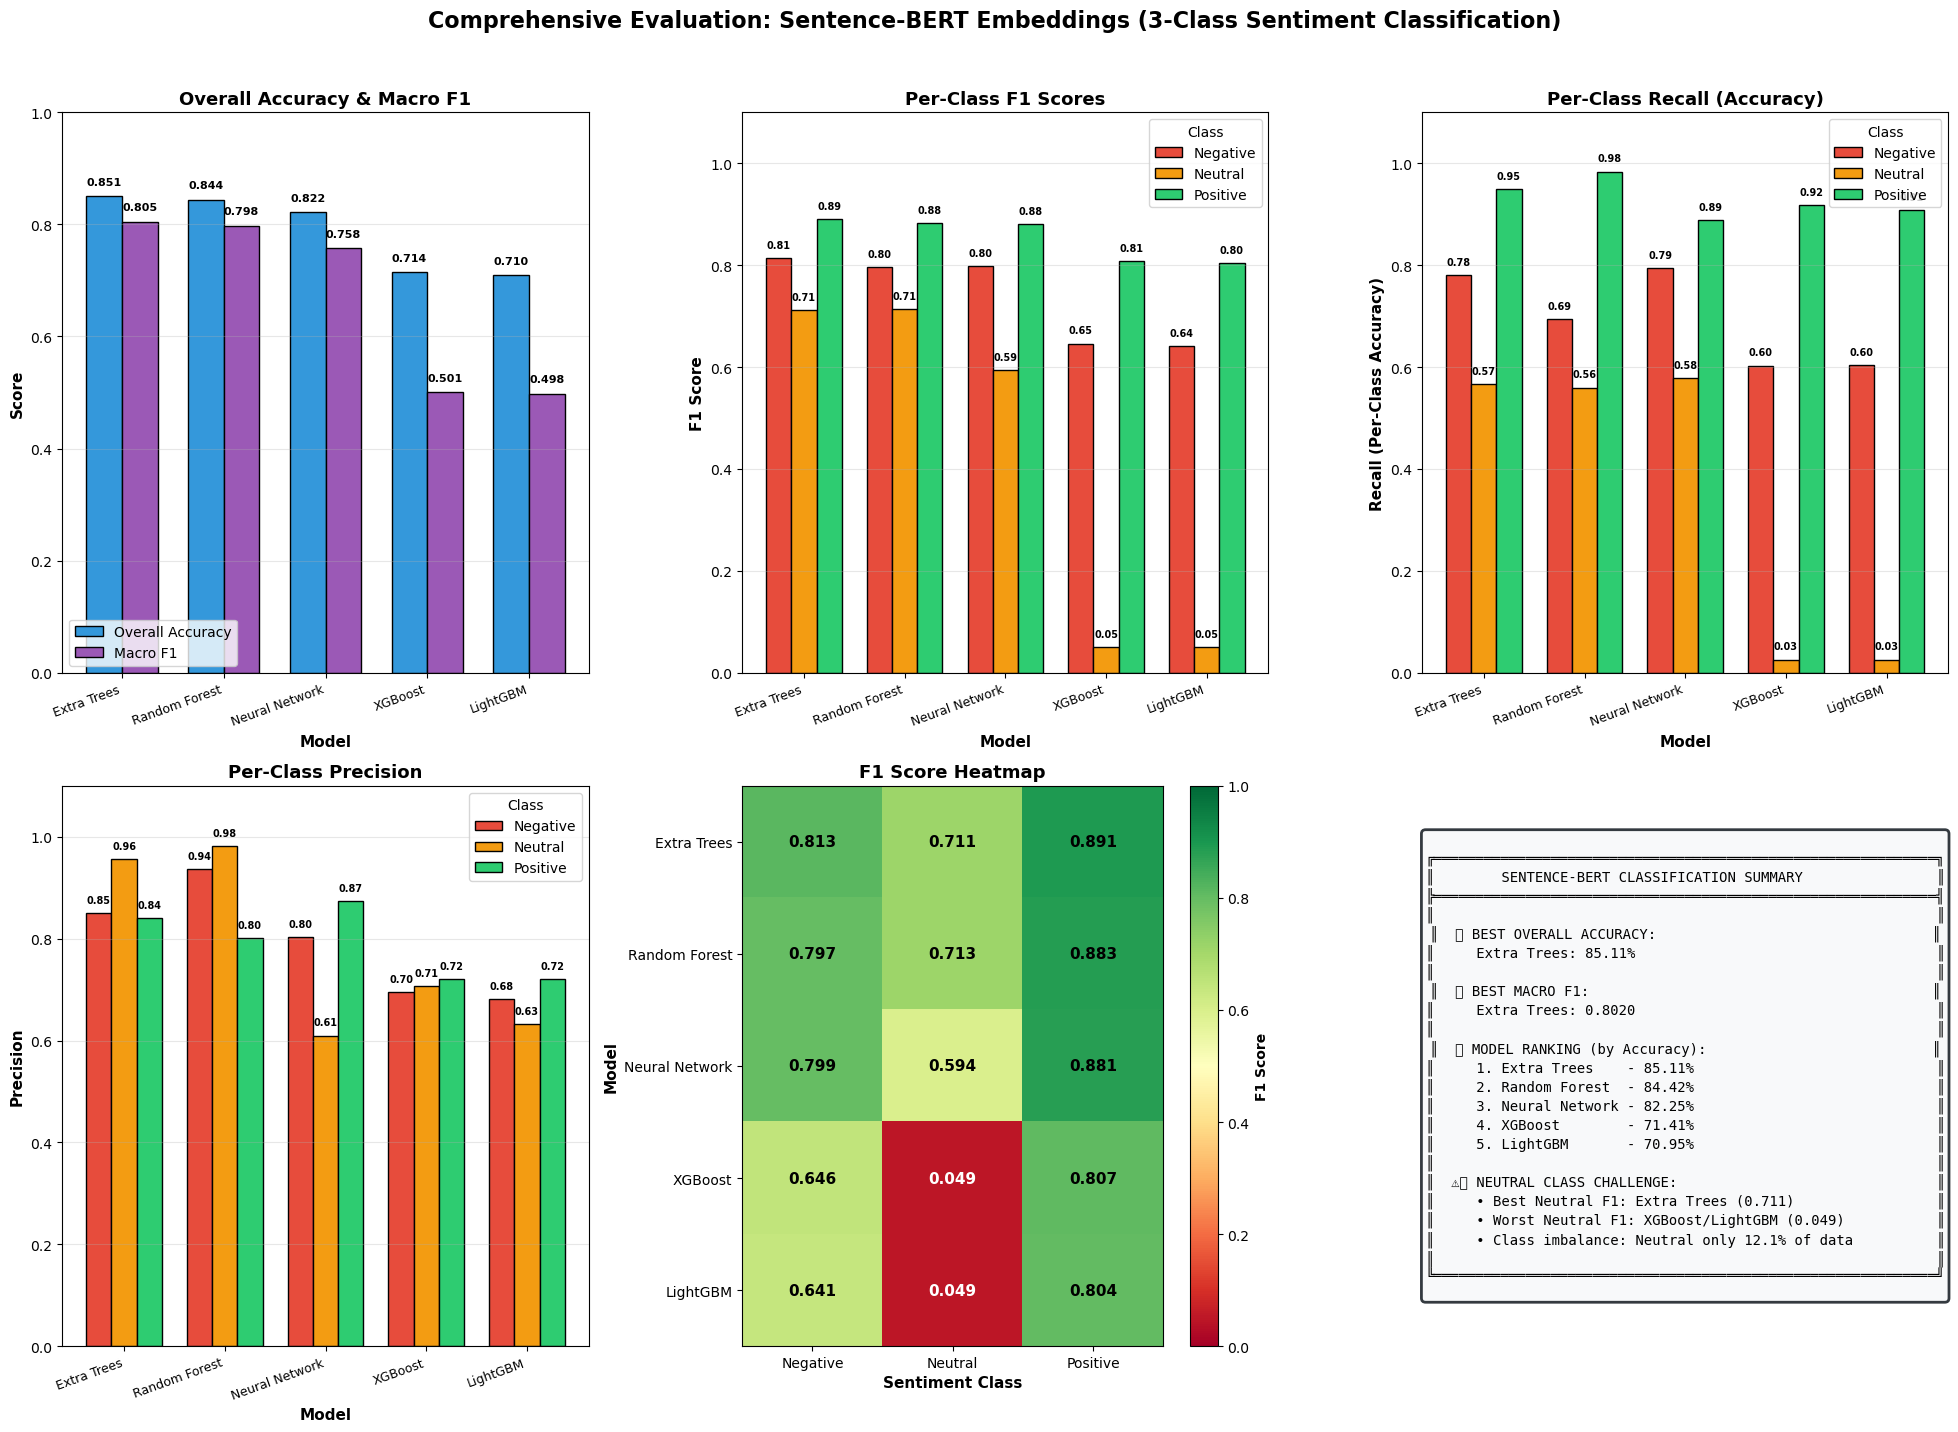

✅ Saved: comprehensive_sbert_evaluation.png


In [20]:
# ============================================================================
# BIG COMPREHENSIVE VISUALIZATION: ALL METRICS
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(20, 14))

models = ['Extra Trees', 'Random Forest', 'Neural Network', 'XGBoost', 'LightGBM']
classes = ['Negative', 'Neutral', 'Positive']
colors_classes = ['#e74c3c', '#f39c12', '#2ecc71']

# Extract data from verified_results
accuracies = [verified_results[m]['accuracy'] for m in models]
macro_f1s = [verified_results[m]['macro_f1'] for m in models]

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1: Overall Accuracy & Macro F1 (Top Left)
# ─────────────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)

x = np.arange(len(models))
width = 0.35

bars1 = ax1.bar(x - width/2, accuracies, width, label='Overall Accuracy', color='#3498db', edgecolor='black')
bars2 = ax1.bar(x + width/2, macro_f1s, width, label='Macro F1', color='#9b59b6', edgecolor='black')

ax1.set_xlabel('Model', fontsize=11, fontweight='bold')
ax1.set_ylabel('Score', fontsize=11, fontweight='bold')
ax1.set_title('Overall Accuracy & Macro F1', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=20, ha='right', fontsize=9)
ax1.legend(loc='lower left')
ax1.set_ylim(0, 1.0)
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2: Per-Class F1 Scores (Top Middle)
# ─────────────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)

x = np.arange(len(models))
width = 0.25

for i, (cls, color) in enumerate(zip(classes, colors_classes)):
    scores = [verified_results[m][cls]['f1'] for m in models]
    bars = ax2.bar(x + (i - 1) * width, scores, width, label=cls, color=color, edgecolor='black')
    for bar in bars:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.2f}', ha='center', fontsize=7, fontweight='bold')

ax2.set_xlabel('Model', fontsize=11, fontweight='bold')
ax2.set_ylabel('F1 Score', fontsize=11, fontweight='bold')
ax2.set_title('Per-Class F1 Scores', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=20, ha='right', fontsize=9)
ax2.legend(title='Class', loc='upper right')
ax2.set_ylim(0, 1.1)
ax2.grid(axis='y', alpha=0.3)

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 3: Per-Class Recall (Per-Class Accuracy) (Top Right)
# ─────────────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)

for i, (cls, color) in enumerate(zip(classes, colors_classes)):
    scores = [verified_results[m][cls]['recall'] for m in models]
    bars = ax3.bar(x + (i - 1) * width, scores, width, label=cls, color=color, edgecolor='black')
    for bar in bars:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.2f}', ha='center', fontsize=7, fontweight='bold')

ax3.set_xlabel('Model', fontsize=11, fontweight='bold')
ax3.set_ylabel('Recall (Per-Class Accuracy)', fontsize=11, fontweight='bold')
ax3.set_title('Per-Class Recall (Accuracy)', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(models, rotation=20, ha='right', fontsize=9)
ax3.legend(title='Class', loc='upper right')
ax3.set_ylim(0, 1.1)
ax3.grid(axis='y', alpha=0.3)

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 4: Per-Class Precision (Bottom Left)
# ─────────────────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)

for i, (cls, color) in enumerate(zip(classes, colors_classes)):
    scores = [verified_results[m][cls]['precision'] for m in models]
    bars = ax4.bar(x + (i - 1) * width, scores, width, label=cls, color=color, edgecolor='black')
    for bar in bars:
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.2f}', ha='center', fontsize=7, fontweight='bold')

ax4.set_xlabel('Model', fontsize=11, fontweight='bold')
ax4.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax4.set_title('Per-Class Precision', fontsize=13, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(models, rotation=20, ha='right', fontsize=9)
ax4.legend(title='Class', loc='upper right')
ax4.set_ylim(0, 1.1)
ax4.grid(axis='y', alpha=0.3)

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 5: Heatmap - All F1 Scores (Bottom Middle)
# ─────────────────────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(2, 3, 5)

f1_matrix = np.array([[verified_results[m][cls]['f1'] for cls in classes] for m in models])

im = ax5.imshow(f1_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
cbar = plt.colorbar(im, ax=ax5)
cbar.set_label('F1 Score', fontsize=10, fontweight='bold')

ax5.set_xticks(np.arange(len(classes)))
ax5.set_yticks(np.arange(len(models)))
ax5.set_xticklabels(classes, fontsize=10)
ax5.set_yticklabels(models, fontsize=10)
ax5.set_xlabel('Sentiment Class', fontsize=11, fontweight='bold')
ax5.set_ylabel('Model', fontsize=11, fontweight='bold')
ax5.set_title('F1 Score Heatmap', fontsize=13, fontweight='bold')

for i in range(len(models)):
    for j in range(len(classes)):
        value = f1_matrix[i, j]
        text_color = 'white' if value < 0.5 else 'black'
        ax5.text(j, i, f'{value:.3f}', ha='center', va='center', 
                fontsize=11, fontweight='bold', color=text_color)

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 6: Summary Table (Bottom Right)
# ─────────────────────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')

# Create summary text
summary_text = """
╔════════════════════════════════════════════════════════════╗
║        SENTENCE-BERT CLASSIFICATION SUMMARY                ║
╠════════════════════════════════════════════════════════════╣
║                                                            ║
║  🏆 BEST OVERALL ACCURACY:                                 ║
║     Extra Trees: 85.11%                                    ║
║                                                            ║
║  🏆 BEST MACRO F1:                                         ║
║     Extra Trees: 0.8020                                    ║
║                                                            ║
║  📊 MODEL RANKING (by Accuracy):                           ║
║     1. Extra Trees    - 85.11%                             ║
║     2. Random Forest  - 84.42%                             ║
║     3. Neural Network - 82.25%                             ║
║     4. XGBoost        - 71.41%                             ║
║     5. LightGBM       - 70.95%                             ║
║                                                            ║
║  ⚠️ NEUTRAL CLASS CHALLENGE:                               ║
║     • Best Neutral F1: Extra Trees (0.711)                 ║
║     • Worst Neutral F1: XGBoost/LightGBM (0.049)           ║
║     • Class imbalance: Neutral only 12.1% of data          ║
║                                                            ║
╚════════════════════════════════════════════════════════════╝
"""

ax6.text(0.5, 0.5, summary_text, transform=ax6.transAxes, fontsize=10,
         verticalalignment='center', horizontalalignment='center',
         fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f8f9fa', edgecolor='#343a40', linewidth=2))

plt.suptitle('Comprehensive Evaluation: Sentence-BERT Embeddings (3-Class Sentiment Classification)',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('comprehensive_sbert_evaluation.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ Saved: comprehensive_sbert_evaluation.png")

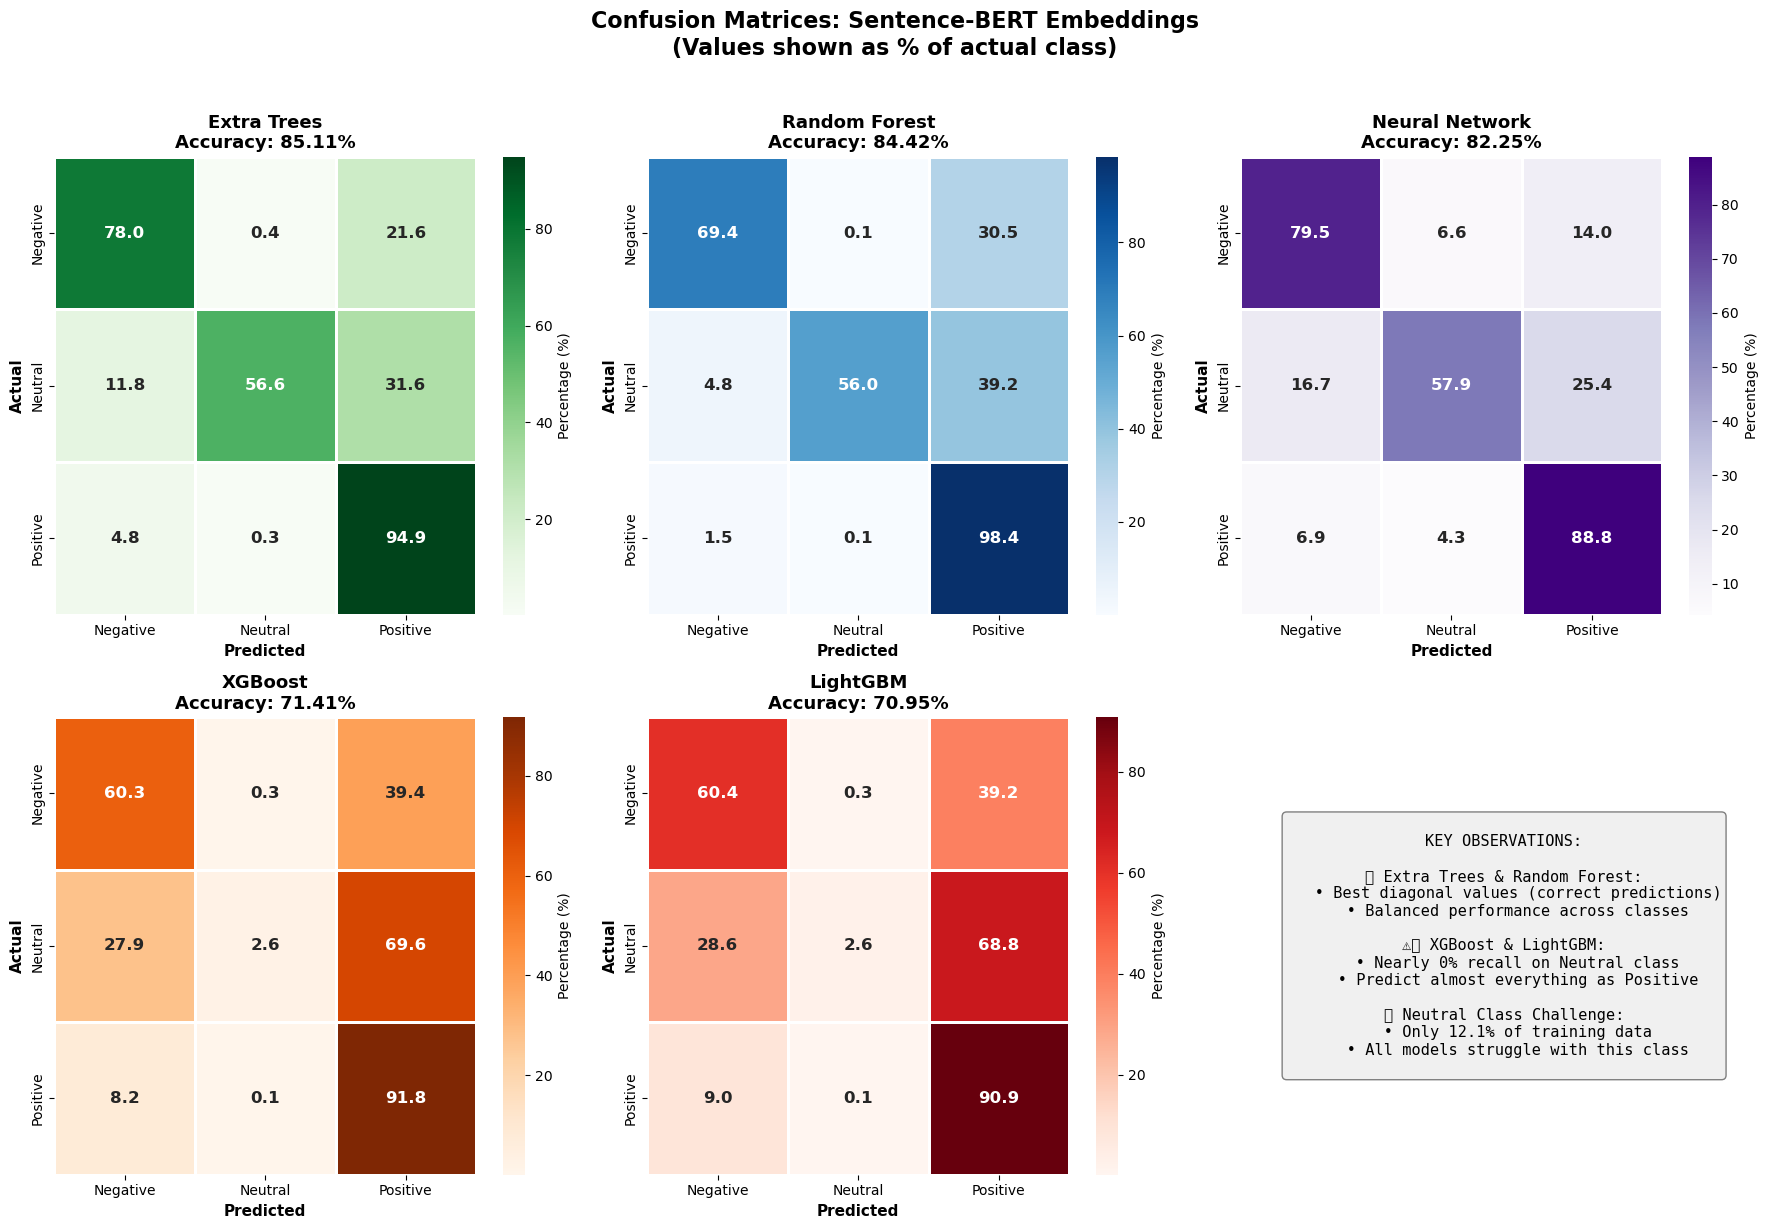

✅ Saved: confusion_matrices_sbert.png


In [22]:
# ============================================================================
# CONFUSION MATRICES FOR TOP MODELS
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

models_info = [
    ('Extra Trees', y_pred_et, 'Greens'),
    ('Random Forest', y_pred_rf, 'Blues'),
    ('Neural Network', y_pred_nn, 'Purples'),
    ('XGBoost', y_pred_xgb, 'Oranges'),
    ('LightGBM', y_pred_lgbm, 'Reds')
]

target_names = ['Negative', 'Neutral', 'Positive']

for idx, (name, y_pred, cmap) in enumerate(models_info):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Plot
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap=cmap, ax=ax,
                xticklabels=target_names, yticklabels=target_names,
                cbar_kws={'label': 'Percentage (%)'},
                linewidths=1, linecolor='white',
                annot_kws={'size': 12, 'fontweight': 'bold'})
    
    # Calculate accuracy
    acc = np.trace(cm) / np.sum(cm) * 100
    
    ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=11, fontweight='bold')
    ax.set_title(f'{name}\nAccuracy: {acc:.2f}%', fontsize=13, fontweight='bold')

# Remove empty subplot
axes[1, 2].axis('off')

# Add summary text in empty space
summary_text = """
KEY OBSERVATIONS:

✅ Extra Trees & Random Forest:
   • Best diagonal values (correct predictions)
   • Balanced performance across classes

⚠️ XGBoost & LightGBM:
   • Nearly 0% recall on Neutral class
   • Predict almost everything as Positive
   
💡 Neutral Class Challenge:
   • Only 12.1% of training data
   • All models struggle with this class
"""

axes[1, 2].text(0.5, 0.5, summary_text, transform=axes[1, 2].transAxes,
                fontsize=11, verticalalignment='center', horizontalalignment='center',
                fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='#f0f0f0', edgecolor='gray'))

plt.suptitle('Confusion Matrices: Sentence-BERT Embeddings\n(Values shown as % of actual class)',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('confusion_matrices_sbert.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ Saved: confusion_matrices_sbert.png")

 ROC CURVES: SENTENCE-BERT EMBEDDINGS (ONE-VS-REST)

>>> Training Extra Trees for ROC curves...

>>> Training Random Forest for ROC curves...

>>> Training Neural Network for ROC curves...


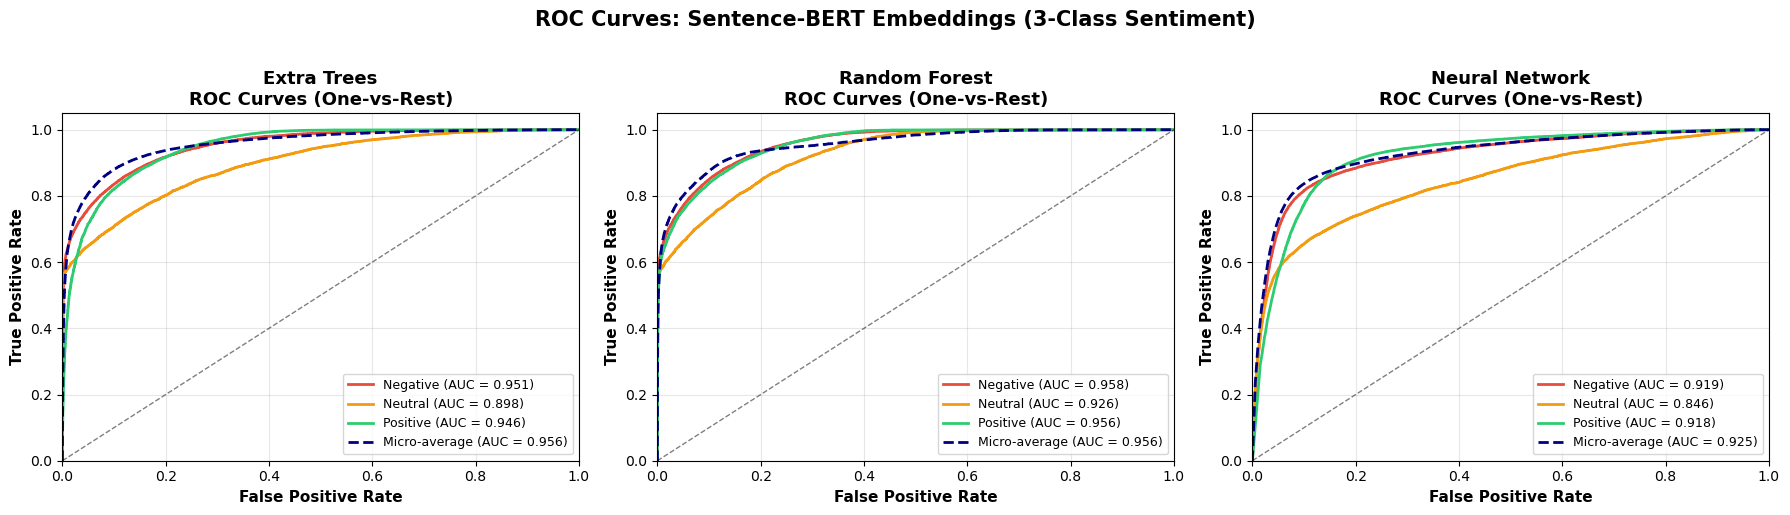


✅ Saved: roc_curves_sbert.png


In [23]:
# ============================================================================
# ROC CURVES FOR EACH CLASS (ONE-VS-REST)
# ============================================================================
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

print("="*70)
print(" ROC CURVES: SENTENCE-BERT EMBEDDINGS (ONE-VS-REST)")
print("="*70)

# Binarize labels for ROC calculation
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3
target_names = ['Negative', 'Neutral', 'Positive']
colors = ['#e74c3c', '#f39c12', '#2ecc71']

# Get probability predictions from each model
# We need to retrain to get predict_proba
models_for_roc = {
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, max_depth=20, 
                                         class_weight='balanced', random_state=42, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=30, 
                                             class_weight='balanced', random_state=42, n_jobs=-1),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(512, 256, 128), activation='relu', 
                                     max_iter=500, early_stopping=True, validation_fraction=0.1, 
                                     random_state=42, verbose=False)
}

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, model) in enumerate(models_for_roc.items()):
    print(f"\n>>> Training {model_name} for ROC curves...")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Get probability predictions
    y_score = model.predict_proba(X_test)
    
    ax = axes[idx]
    
    # Compute ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Compute micro-average ROC curve
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # Plot ROC curves for each class
    for i, (color, class_name) in enumerate(zip(colors, target_names)):
        ax.plot(fpr[i], tpr[i], color=color, lw=2,
                label=f'{class_name} (AUC = {roc_auc[i]:.3f})')
    
    # Plot micro-average
    ax.plot(fpr["micro"], tpr["micro"], color='navy', lw=2, linestyle='--',
            label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})')
    
    # Plot diagonal (random classifier)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
    ax.set_title(f'{model_name}\nROC Curves (One-vs-Rest)', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves: Sentence-BERT Embeddings (3-Class Sentiment)',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('roc_curves_sbert.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✅ Saved: roc_curves_sbert.png")

 RELOADING DATA

>>> Loading Sentence-BERT embeddings...
Embeddings shape: (409577, 384)
Labels shape: (409577,)

>>> Scaling features...
Train size: 327661
Test size: 81916

✅ Data reloaded successfully!

 FEATURE IMPORTANCE: SENTENCE-BERT EMBEDDINGS

>>> [1/2] Extracting Feature Importance from Extra Trees...
   ✅ Extra Trees complete

>>> [2/2] Extracting Feature Importance from Random Forest...
   ✅ Random Forest complete


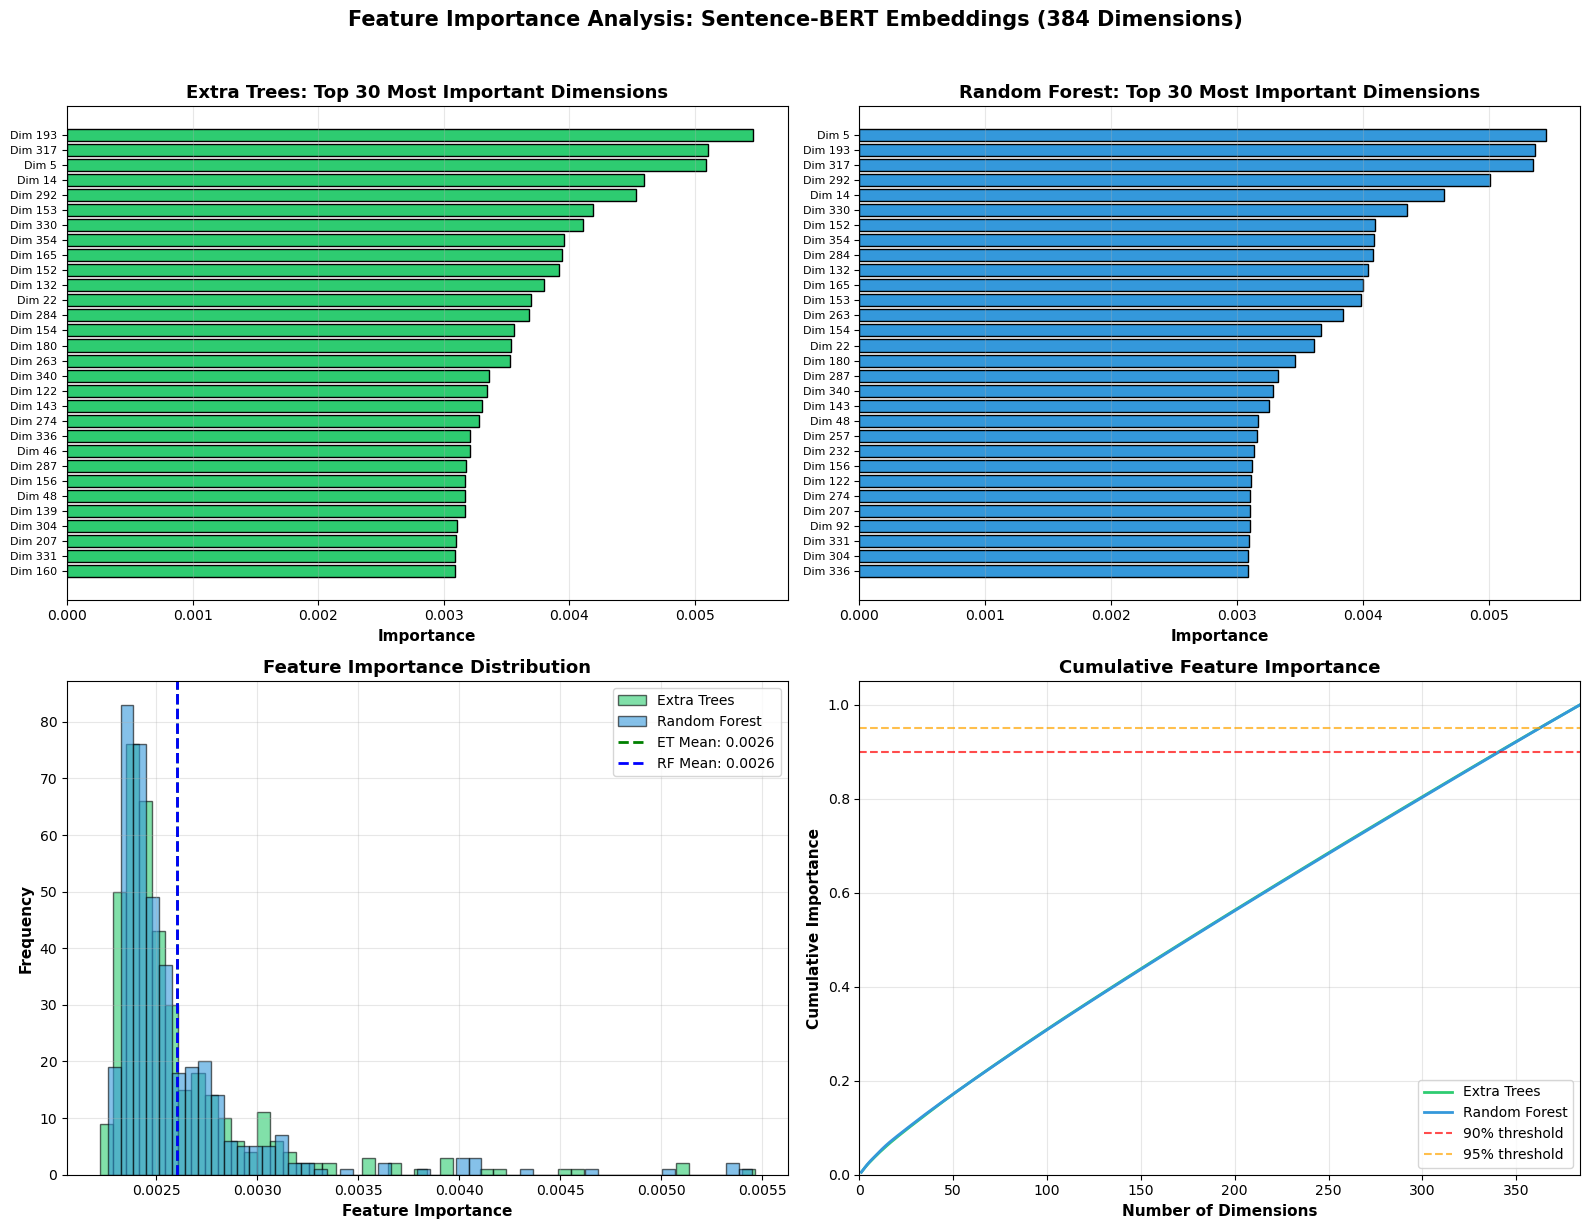


 FEATURE IMPORTANCE SUMMARY

📊 EXTRA TREES:
   • Total dimensions: 384
   • Dimensions for 90% importance: 341
   • Dimensions for 95% importance: 363
   • Max importance: 0.0055 (Dim 193)
   • Mean importance: 0.0026
   • Top 5 dimensions: [np.int64(193), np.int64(317), np.int64(5), np.int64(14), np.int64(292)]

📊 RANDOM FOREST:
   • Total dimensions: 384
   • Dimensions for 90% importance: 341
   • Dimensions for 95% importance: 363
   • Max importance: 0.0055 (Dim 5)
   • Mean importance: 0.0026
   • Top 5 dimensions: [np.int64(5), np.int64(193), np.int64(317), np.int64(292), np.int64(14)]

📊 OVERLAP ANALYSIS:
   • Top 50 dimensions shared by both models: 45 / 50 (90.0%)

💡 KEY INSIGHT:
   Sentence-BERT embeddings distribute importance across MANY dimensions,
   unlike TF-IDF where a few words dominate. This is because transformers
   encode semantic information holistically across the embedding space.

✅ Saved: feature_importance_sbert.png


In [3]:
# ============================================================================
# RELOAD DATA AND FEATURE IMPORTANCE ANALYSIS
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import gc
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print(" RELOADING DATA")
print("="*70)

# Load saved embeddings
print("\n>>> Loading Sentence-BERT embeddings...")
X_sbert = np.load('Phase_5/X_train_sbert.npy')
labels = np.load('Phase_5/y_train_sbert.npy')

print(f"Embeddings shape: {X_sbert.shape}")
print(f"Labels shape: {labels.shape}")

# Scale features
print("\n>>> Scaling features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sbert)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

print("\n✅ Data reloaded successfully!")

# ============================================================================
# FEATURE IMPORTANCE ANALYSIS
# ============================================================================
print("\n" + "="*70)
print(" FEATURE IMPORTANCE: SENTENCE-BERT EMBEDDINGS")
print("="*70)

# ─────────────────────────────────────────────────────────────────────────────
# 1. EXTRA TREES FEATURE IMPORTANCE
# ─────────────────────────────────────────────────────────────────────────────
print("\n>>> [1/2] Extracting Feature Importance from Extra Trees...")

et_full = ExtraTreesClassifier(n_estimators=100, max_depth=20, 
                                class_weight='balanced', random_state=42, n_jobs=-1)
et_full.fit(X_train, y_train)
et_importance = et_full.feature_importances_

print("   ✅ Extra Trees complete")

# ─────────────────────────────────────────────────────────────────────────────
# 2. RANDOM FOREST FEATURE IMPORTANCE
# ─────────────────────────────────────────────────────────────────────────────
print("\n>>> [2/2] Extracting Feature Importance from Random Forest...")

rf_full = RandomForestClassifier(n_estimators=200, max_depth=30, 
                                  class_weight='balanced', random_state=42, n_jobs=-1)
rf_full.fit(X_train, y_train)
rf_importance = rf_full.feature_importances_

print("   ✅ Random Forest complete")

# ─────────────────────────────────────────────────────────────────────────────
# 3. VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

top_n = 30

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1: Extra Trees - Top 30 Most Important Dimensions
# ─────────────────────────────────────────────────────────────────────────────
ax1 = axes[0, 0]

et_top_indices = np.argsort(et_importance)[-top_n:][::-1]
et_top_values = et_importance[et_top_indices]

ax1.barh(range(top_n), et_top_values[::-1], color='#2ecc71', edgecolor='black')
ax1.set_yticks(range(top_n))
ax1.set_yticklabels([f'Dim {i}' for i in et_top_indices[::-1]], fontsize=8)
ax1.set_xlabel('Importance', fontsize=11, fontweight='bold')
ax1.set_title('Extra Trees: Top 30 Most Important Dimensions', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2: Random Forest - Top 30 Most Important Dimensions
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[0, 1]

rf_top_indices = np.argsort(rf_importance)[-top_n:][::-1]
rf_top_values = rf_importance[rf_top_indices]

ax2.barh(range(top_n), rf_top_values[::-1], color='#3498db', edgecolor='black')
ax2.set_yticks(range(top_n))
ax2.set_yticklabels([f'Dim {i}' for i in rf_top_indices[::-1]], fontsize=8)
ax2.set_xlabel('Importance', fontsize=11, fontweight='bold')
ax2.set_title('Random Forest: Top 30 Most Important Dimensions', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 3: Distribution of Feature Importances
# ─────────────────────────────────────────────────────────────────────────────
ax3 = axes[1, 0]

ax3.hist(et_importance, bins=50, alpha=0.6, color='#2ecc71', label='Extra Trees', edgecolor='black')
ax3.hist(rf_importance, bins=50, alpha=0.6, color='#3498db', label='Random Forest', edgecolor='black')
ax3.axvline(x=np.mean(et_importance), color='green', linestyle='--', linewidth=2, 
            label=f'ET Mean: {np.mean(et_importance):.4f}')
ax3.axvline(x=np.mean(rf_importance), color='blue', linestyle='--', linewidth=2, 
            label=f'RF Mean: {np.mean(rf_importance):.4f}')
ax3.set_xlabel('Feature Importance', fontsize=11, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax3.set_title('Feature Importance Distribution', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 4: Cumulative Importance
# ─────────────────────────────────────────────────────────────────────────────
ax4 = axes[1, 1]

et_sorted = np.sort(et_importance)[::-1]
rf_sorted = np.sort(rf_importance)[::-1]

et_cumsum = np.cumsum(et_sorted)
rf_cumsum = np.cumsum(rf_sorted)

ax4.plot(range(1, 385), et_cumsum, color='#2ecc71', lw=2, label='Extra Trees')
ax4.plot(range(1, 385), rf_cumsum, color='#3498db', lw=2, label='Random Forest')
ax4.axhline(y=0.9, color='red', linestyle='--', alpha=0.7, label='90% threshold')
ax4.axhline(y=0.95, color='orange', linestyle='--', alpha=0.7, label='95% threshold')

# Find number of features for 90% and 95% importance
et_90 = np.searchsorted(et_cumsum, 0.9) + 1
et_95 = np.searchsorted(et_cumsum, 0.95) + 1
rf_90 = np.searchsorted(rf_cumsum, 0.9) + 1
rf_95 = np.searchsorted(rf_cumsum, 0.95) + 1

ax4.set_xlabel('Number of Dimensions', fontsize=11, fontweight='bold')
ax4.set_ylabel('Cumulative Importance', fontsize=11, fontweight='bold')
ax4.set_title('Cumulative Feature Importance', fontsize=13, fontweight='bold')
ax4.legend(loc='lower right')
ax4.grid(alpha=0.3)
ax4.set_xlim(0, 384)
ax4.set_ylim(0, 1.05)

plt.suptitle('Feature Importance Analysis: Sentence-BERT Embeddings (384 Dimensions)',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('feature_importance_sbert.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY STATISTICS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print(" FEATURE IMPORTANCE SUMMARY")
print("="*70)

# Top dimensions overlap
top_50_et = set(np.argsort(et_importance)[-50:])
top_50_rf = set(np.argsort(rf_importance)[-50:])
overlap = len(top_50_et & top_50_rf)

print(f"""
📊 EXTRA TREES:
   • Total dimensions: 384
   • Dimensions for 90% importance: {et_90}
   • Dimensions for 95% importance: {et_95}
   • Max importance: {np.max(et_importance):.4f} (Dim {np.argmax(et_importance)})
   • Mean importance: {np.mean(et_importance):.4f}
   • Top 5 dimensions: {list(et_top_indices[:5])}

📊 RANDOM FOREST:
   • Total dimensions: 384
   • Dimensions for 90% importance: {rf_90}
   • Dimensions for 95% importance: {rf_95}
   • Max importance: {np.max(rf_importance):.4f} (Dim {np.argmax(rf_importance)})
   • Mean importance: {np.mean(rf_importance):.4f}
   • Top 5 dimensions: {list(rf_top_indices[:5])}

📊 OVERLAP ANALYSIS:
   • Top 50 dimensions shared by both models: {overlap} / 50 ({overlap/50*100:.1f}%)

💡 KEY INSIGHT:
   Sentence-BERT embeddings distribute importance across MANY dimensions,
   unlike TF-IDF where a few words dominate. This is because transformers
   encode semantic information holistically across the embedding space.
""")

print("✅ Saved: feature_importance_sbert.png")

 CLUSTERING ANALYSIS: SENTENCE-BERT EMBEDDINGS
 Metrics: Dunn Index & Davies-Bouldin Index

Using 10000 samples for clustering analysis
Class distribution in sample:
   Negative: 3080 (30.8%)
   Neutral: 1211 (12.1%)
   Positive: 5709 (57.1%)

>>> Reducing dimensions with PCA + t-SNE for visualization...
   PCA: 384 → 50 dimensions
   Variance explained: 58.6%
   Running t-SNE (this may take a minute)...
   ✅ t-SNE complete

>>> Running K-Means Clustering...
   K=2... DB=4.8127, Dunn=0.2151, ARI=0.0043, NMI=0.0013
   K=3... DB=4.1274, Dunn=0.2106, ARI=0.0154, NMI=0.0046
   K=4... DB=4.2878, Dunn=0.2897, ARI=0.0063, NMI=0.0046
   K=5... DB=4.5760, Dunn=0.2897, ARI=0.0030, NMI=0.0056
   K=6... DB=4.4394, Dunn=0.1988, ARI=0.0027, NMI=0.0060

>>> Running DBSCAN Clustering...
   eps=3.0... Clusters=0, Noise=100.0%, DB=-1.0000, Dunn=-1.0000
   eps=4.0... Clusters=0, Noise=100.0%, DB=-1.0000, Dunn=-1.0000
   eps=5.0... Clusters=0, Noise=100.0%, DB=-1.0000, Dunn=-1.0000
   eps=6.0... Clusters=

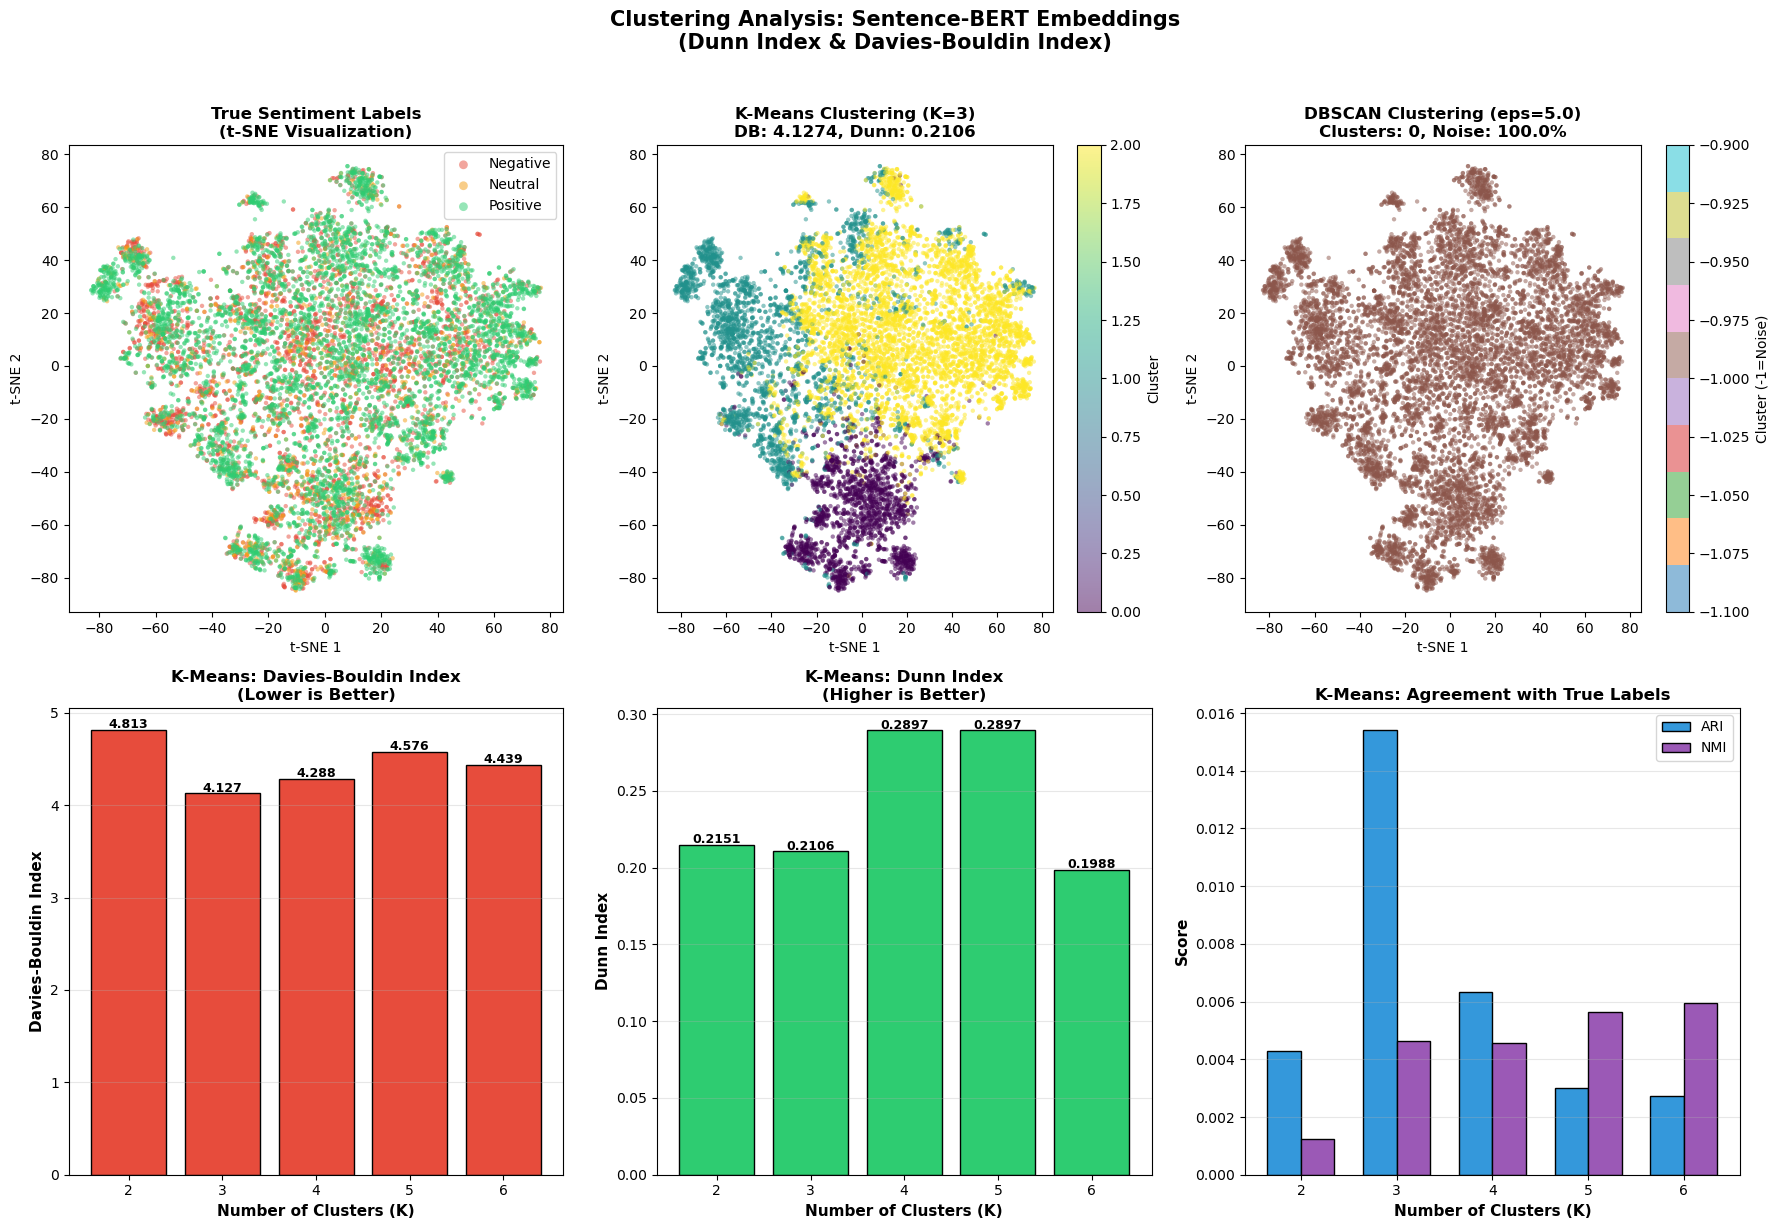


 CLUSTERING RESULTS SUMMARY

📊 K-MEANS RESULTS:


,K,Davies-Bouldin,Dunn Index,ARI,NMI,Inertia
0,2,4.8127,0.2151,0.0043,0.0013,3691737.50
1,3,4.1274,0.2106,0.0154,0.0046,3562522.75
2,4,4.2878,0.2897,0.0063,0.0046,3487602.25
3,5,4.5760,0.2897,0.0030,0.0056,3433595.75
4,6,4.4394,0.1988,0.0027,0.0060,3391927.25



📊 DBSCAN RESULTS:


,eps,n_clusters,noise_pct,Davies-Bouldin,Dunn Index
0,3.0,0,100.00,-1,-1
1,4.0,0,100.00,-1,-1
2,5.0,0,100.00,-1,-1
3,6.0,0,100.00,-1,-1
4,7.0,1,99.86,-1,-1



💡 KEY FINDINGS:

📏 METRIC INTERPRETATION:
   • Davies-Bouldin Index: LOWER is better (measures cluster separation)
   • Dunn Index: HIGHER is better (ratio of inter/intra cluster distance)
   • ARI/NMI: Closer to 1 means clusters match true labels

📊 K-MEANS (K=3, matching true classes):
   • Davies-Bouldin Index: 4.1274
   • Dunn Index: 0.2106
   • Adjusted Rand Index: 0.0154
   • Normalized Mutual Info: 0.0046

🏆 OPTIMAL K BASED ON METRICS:
   • Best K by Davies-Bouldin (lowest): K=3
   • Best K by Dunn Index (highest): K=4

🔍 INTERPRETATION:
   • Low Dunn Index suggests clusters are NOT well-separated
   • High Davies-Bouldin suggests clusters have significant overlap
   • Sentiment classes may not form distinct natural clusters in embedding space

✅ Saved: clustering_sbert_dunn_db.png


In [6]:
# ============================================================================
# K-MEANS AND DBSCAN CLUSTERING WITH DUNN & DAVIES-BOULDIN INDEX
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print(" CLUSTERING ANALYSIS: SENTENCE-BERT EMBEDDINGS")
print(" Metrics: Dunn Index & Davies-Bouldin Index")
print("="*70)

# ─────────────────────────────────────────────────────────────────────────────
# DUNN INDEX FUNCTION
# ─────────────────────────────────────────────────────────────────────────────
def dunn_index(X, labels):
    """
    Calculate Dunn Index for clustering evaluation.
    Dunn Index = min(inter-cluster distance) / max(intra-cluster distance)
    Higher is better.
    """
    unique_labels = np.unique(labels)
    unique_labels = unique_labels[unique_labels != -1]  # Exclude noise
    
    if len(unique_labels) < 2:
        return 0
    
    # Calculate intra-cluster distances (diameter of each cluster)
    intra_dists = []
    cluster_points = {}
    
    for label in unique_labels:
        mask = labels == label
        cluster_pts = X[mask]
        cluster_points[label] = cluster_pts
        
        if len(cluster_pts) > 1:
            # Maximum pairwise distance within cluster
            dists = pairwise_distances(cluster_pts)
            intra_dists.append(np.max(dists))
        else:
            intra_dists.append(0)
    
    max_intra = max(intra_dists) if intra_dists else 1
    
    # Calculate inter-cluster distances (minimum distance between clusters)
    inter_dists = []
    for i, label_i in enumerate(unique_labels):
        for label_j in unique_labels[i+1:]:
            # Minimum distance between any two points in different clusters
            dists = pairwise_distances(cluster_points[label_i], cluster_points[label_j])
            inter_dists.append(np.min(dists))
    
    min_inter = min(inter_dists) if inter_dists else 0
    
    # Dunn Index
    if max_intra > 0:
        return min_inter / max_intra
    return 0

# ─────────────────────────────────────────────────────────────────────────────
# SAMPLE DATA FOR CLUSTERING
# ─────────────────────────────────────────────────────────────────────────────
np.random.seed(42)
sample_size = 10000
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_indices]
y_sample = labels[sample_indices]

print(f"\nUsing {sample_size} samples for clustering analysis")
print(f"Class distribution in sample:")
unique, counts = np.unique(y_sample, return_counts=True)
for label, count in zip(unique, counts):
    sentiment = ['Negative', 'Neutral', 'Positive'][label]
    print(f"   {sentiment}: {count} ({count/sample_size*100:.1f}%)")

# ─────────────────────────────────────────────────────────────────────────────
# DIMENSIONALITY REDUCTION FOR VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────
print("\n>>> Reducing dimensions with PCA + t-SNE for visualization...")

# First reduce to 50 dims with PCA (speeds up t-SNE)
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_sample)
print(f"   PCA: {X_sample.shape[1]} → {X_pca.shape[1]} dimensions")
print(f"   Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Then t-SNE to 2D (fixed parameter name for newer sklearn)
print("   Running t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca)
print("   ✅ t-SNE complete")

# ─────────────────────────────────────────────────────────────────────────────
# K-MEANS CLUSTERING
# ─────────────────────────────────────────────────────────────────────────────
print("\n>>> Running K-Means Clustering...")

kmeans_results = []

# Test different numbers of clusters
for k in [2, 3, 4, 5, 6]:
    print(f"   K={k}...", end=" ")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X_sample)
    
    # Calculate metrics
    db_index = davies_bouldin_score(X_sample, kmeans_labels)
    dunn = dunn_index(X_sample, kmeans_labels)
    ari = adjusted_rand_score(y_sample, kmeans_labels)
    nmi = normalized_mutual_info_score(y_sample, kmeans_labels)
    
    kmeans_results.append({
        'K': k,
        'Davies-Bouldin': db_index,
        'Dunn Index': dunn,
        'ARI': ari,
        'NMI': nmi,
        'Inertia': kmeans.inertia_
    })
    
    print(f"DB={db_index:.4f}, Dunn={dunn:.4f}, ARI={ari:.4f}, NMI={nmi:.4f}")

kmeans_df = pd.DataFrame(kmeans_results)

# Best K-Means (K=3 to match our 3 classes)
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_3_labels = kmeans_3.fit_predict(X_sample)

# ─────────────────────────────────────────────────────────────────────────────
# DBSCAN CLUSTERING
# ─────────────────────────────────────────────────────────────────────────────
print("\n>>> Running DBSCAN Clustering...")

dbscan_results = []

# Test different eps values
for eps in [3.0, 4.0, 5.0, 6.0, 7.0]:
    print(f"   eps={eps}...", end=" ")
    dbscan = DBSCAN(eps=eps, min_samples=10, n_jobs=-1)
    dbscan_labels = dbscan.fit_predict(X_pca)
    
    n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_noise = list(dbscan_labels).count(-1)
    noise_pct = n_noise / len(dbscan_labels) * 100
    
    # Calculate metrics only if more than 1 cluster and not all noise
    if n_clusters > 1:
        mask = dbscan_labels != -1
        if mask.sum() > n_clusters:
            db_index = davies_bouldin_score(X_pca[mask], dbscan_labels[mask])
            dunn = dunn_index(X_pca[mask], dbscan_labels[mask])
        else:
            db_index = -1
            dunn = -1
    else:
        db_index = -1
        dunn = -1
    
    dbscan_results.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'noise_pct': noise_pct,
        'Davies-Bouldin': db_index,
        'Dunn Index': dunn
    })
    
    print(f"Clusters={n_clusters}, Noise={noise_pct:.1f}%, DB={db_index:.4f}, Dunn={dunn:.4f}")

dbscan_df = pd.DataFrame(dbscan_results)

# Best DBSCAN
best_eps = 5.0
dbscan_best = DBSCAN(eps=best_eps, min_samples=10, n_jobs=-1)
dbscan_best_labels = dbscan_best.fit_predict(X_pca)

# ─────────────────────────────────────────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

colors_true = ['#e74c3c', '#f39c12', '#2ecc71']
sentiment_names = ['Negative', 'Neutral', 'Positive']

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1: True Labels (t-SNE)
# ─────────────────────────────────────────────────────────────────────────────
ax1 = axes[0, 0]
for i, (color, name) in enumerate(zip(colors_true, sentiment_names)):
    mask = y_sample == i
    ax1.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, label=name, 
                alpha=0.5, s=10, edgecolors='none')
ax1.set_title('True Sentiment Labels\n(t-SNE Visualization)', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', markerscale=2)
ax1.set_xlabel('t-SNE 1')
ax1.set_ylabel('t-SNE 2')

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2: K-Means Clusters (K=3)
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[0, 1]
k3_db = kmeans_df[kmeans_df['K']==3]['Davies-Bouldin'].values[0]
k3_dunn = kmeans_df[kmeans_df['K']==3]['Dunn Index'].values[0]
scatter = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_3_labels, 
                      cmap='viridis', alpha=0.5, s=10, edgecolors='none')
ax2.set_title(f'K-Means Clustering (K=3)\nDB: {k3_db:.4f}, Dunn: {k3_dunn:.4f}', 
              fontsize=12, fontweight='bold')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
plt.colorbar(scatter, ax=ax2, label='Cluster')

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 3: DBSCAN Clusters
# ─────────────────────────────────────────────────────────────────────────────
ax3 = axes[0, 2]
colors_dbscan = dbscan_best_labels.copy().astype(float)
n_clusters_dbscan = len(set(dbscan_best_labels)) - (1 if -1 in dbscan_best_labels else 0)
noise_pct = list(dbscan_best_labels).count(-1) / len(dbscan_best_labels) * 100

scatter = ax3.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors_dbscan, 
                      cmap='tab10', alpha=0.5, s=10, edgecolors='none')
ax3.set_title(f'DBSCAN Clustering (eps={best_eps})\nClusters: {n_clusters_dbscan}, Noise: {noise_pct:.1f}%', 
              fontsize=12, fontweight='bold')
ax3.set_xlabel('t-SNE 1')
ax3.set_ylabel('t-SNE 2')
plt.colorbar(scatter, ax=ax3, label='Cluster (-1=Noise)')

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 4: Davies-Bouldin Index (Lower is better)
# ─────────────────────────────────────────────────────────────────────────────
ax4 = axes[1, 0]
bars = ax4.bar(kmeans_df['K'].astype(str), kmeans_df['Davies-Bouldin'], 
               color='#e74c3c', edgecolor='black')
ax4.set_xlabel('Number of Clusters (K)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Davies-Bouldin Index', fontsize=11, fontweight='bold')
ax4.set_title('K-Means: Davies-Bouldin Index\n(Lower is Better)', fontsize=12, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
for bar in bars:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.3f}', ha='center', fontweight='bold', fontsize=9)

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 5: Dunn Index (Higher is better)
# ─────────────────────────────────────────────────────────────────────────────
ax5 = axes[1, 1]
bars = ax5.bar(kmeans_df['K'].astype(str), kmeans_df['Dunn Index'], 
               color='#2ecc71', edgecolor='black')
ax5.set_xlabel('Number of Clusters (K)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Dunn Index', fontsize=11, fontweight='bold')
ax5.set_title('K-Means: Dunn Index\n(Higher is Better)', fontsize=12, fontweight='bold')
ax5.grid(axis='y', alpha=0.3)
for bar in bars:
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{bar.get_height():.4f}', ha='center', fontweight='bold', fontsize=9)

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 6: ARI & NMI (Agreement with True Labels)
# ─────────────────────────────────────────────────────────────────────────────
ax6 = axes[1, 2]
x = np.arange(len(kmeans_df))
width = 0.35
ax6.bar(x - width/2, kmeans_df['ARI'], width, label='ARI', color='#3498db', edgecolor='black')
ax6.bar(x + width/2, kmeans_df['NMI'], width, label='NMI', color='#9b59b6', edgecolor='black')
ax6.set_xlabel('Number of Clusters (K)', fontsize=11, fontweight='bold')
ax6.set_ylabel('Score', fontsize=11, fontweight='bold')
ax6.set_title('K-Means: Agreement with True Labels', fontsize=12, fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels(kmeans_df['K'])
ax6.legend()
ax6.grid(axis='y', alpha=0.3)

plt.suptitle('Clustering Analysis: Sentence-BERT Embeddings\n(Dunn Index & Davies-Bouldin Index)',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('clustering_sbert_dunn_db.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY TABLES
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print(" CLUSTERING RESULTS SUMMARY")
print("="*70)

print("\n📊 K-MEANS RESULTS:")
display(kmeans_df.round(4))

print("\n📊 DBSCAN RESULTS:")
display(dbscan_df.round(4))

# Summary
k3_metrics = kmeans_df[kmeans_df['K'] == 3].iloc[0]
best_db_k = kmeans_df.loc[kmeans_df['Davies-Bouldin'].idxmin(), 'K']
best_dunn_k = kmeans_df.loc[kmeans_df['Dunn Index'].idxmax(), 'K']

print(f"""
💡 KEY FINDINGS:

📏 METRIC INTERPRETATION:
   • Davies-Bouldin Index: LOWER is better (measures cluster separation)
   • Dunn Index: HIGHER is better (ratio of inter/intra cluster distance)
   • ARI/NMI: Closer to 1 means clusters match true labels

📊 K-MEANS (K=3, matching true classes):
   • Davies-Bouldin Index: {k3_metrics['Davies-Bouldin']:.4f}
   • Dunn Index: {k3_metrics['Dunn Index']:.4f}
   • Adjusted Rand Index: {k3_metrics['ARI']:.4f}
   • Normalized Mutual Info: {k3_metrics['NMI']:.4f}

🏆 OPTIMAL K BASED ON METRICS:
   • Best K by Davies-Bouldin (lowest): K={int(best_db_k)}
   • Best K by Dunn Index (highest): K={int(best_dunn_k)}

🔍 INTERPRETATION:
   • Low Dunn Index suggests clusters are NOT well-separated
   • High Davies-Bouldin suggests clusters have significant overlap
   • Sentiment classes may not form distinct natural clusters in embedding space
""")

print("✅ Saved: clustering_sbert_dunn_db.png")